# Sprint 11 — Funil de vendas e teste A/A/B no aplicativo

### por Luiz Trajano



---



## Contexto



Trabalho numa startup que vende produtos alimentícios e preciso entender o comportamento dos

usuários dentro do aplicativo. O trabalho tem duas frentes, e as duas saem do mesmo arquivo de log.



A primeira é o **funil de vendas**: por onde o usuário passa até chegar na compra, quantos de fato

chegam lá e em que etapa eles ficam presos.



A segunda é um **teste A/A/B**. Os designers querem trocar as fontes do aplicativo inteiro e os

gerentes acham que o desenho novo vai intimidar o usuário. A decisão vai sair do teste: dois grupos

de controle ficaram com a fonte antiga (246 e 247) e um grupo de teste recebeu a nova (248). Ter

**dois** grupos A não é redundância, é o meu controle de qualidade. Se os dois grupos que receberam

exatamente o mesmo tratamento já diferem entre si, o mecanismo de divisão está torto, e aí qualquer

diferença que eu encontrar contra o grupo B não prova nada.



**A pergunta que a análise precisa responder:** onde o funil perde usuário, e a fonte nova muda o

comportamento deles o suficiente para justificar a troca?

## Índice

- [1. Carregamento e preparação dos dados](#1.-Carregamento-e-preparação-dos-dados)
  - [1.1 Visão geral](#1.1-Visão-geral)
  - [1.2 Renomear as colunas](#1.2-Renomear-as-colunas)
  - [1.3 Ausentes e tipos de dado](#1.3-Ausentes-e-tipos-de-dado)
  - [1.4 Duplicados num log de evento](#1.4-Duplicados-num-log-de-evento)
  - [1.5 Coluna de data e hora e coluna de data](#1.5-Coluna-de-data-e-hora-e-coluna-de-data)
- [2. Estudo e verificação dos dados](#2.-Estudo-e-verificação-dos-dados)
  - [2.1 Quantos eventos e quantos usuários](#2.1-Quantos-eventos-e-quantos-usuários)
  - [2.2 O período que os dados cobrem](#2.2-O-período-que-os-dados-cobrem)
  - [2.3 O corte dos dados incompletos e o que eu perdi](#2.3-O-corte-dos-dados-incompletos-e-o-que-eu-perdi)
  - [2.4 Os três grupos experimentais](#2.4-Os-três-grupos-experimentais)
- [3. O funil de eventos](#3.-O-funil-de-eventos)
  - [3.1 Que eventos existem e com que frequência](#3.1-Que-eventos-existem-e-com-que-frequência)
  - [3.2 Usuários por evento](#3.2-Usuários-por-evento)
  - [3.3 A ordem das etapas](#3.3-A-ordem-das-etapas)
  - [3.4 Conversão de etapa para etapa](#3.4-Conversão-de-etapa-para-etapa)
  - [3.5 Onde eu perco mais usuário](#3.5-Onde-eu-perco-mais-usuário)
- [4. Resultados do experimento](#4.-Resultados-do-experimento)
  - [4.1 Usuários em cada grupo](#4.1-Usuários-em-cada-grupo)
  - [4.2 O teste A/A: 246 contra 247](#4.2-O-teste-A/A:-246-contra-247)
  - [4.3 O grupo de teste contra cada controle](#4.3-O-grupo-de-teste-contra-cada-controle)
  - [4.4 O grupo de teste contra os controles combinados](#4.4-O-grupo-de-teste-contra-os-controles-combinados)
  - [4.5 Nível de significância e o problema dos testes múltiplos](#4.5-Nível-de-significância-e-o-problema-dos-testes-múltiplos)
- [5. Conclusão geral e recomendações](#5.-Conclusão-geral-e-recomendações)

---

## Descrição dos dados — arquivo `logs_exp_us.csv`

Cada linha do log é uma ação de um usuário, ou seja, um evento.

| coluna | descrição |
|---|---|
| `EventName` | nome do evento |
| `DeviceIDHash` | identificador único do usuário |
| `EventTimestamp` | hora do evento |
| `ExpId` | número do experimento: 246 e 247 são os grupos de controle, 248 é o grupo de teste |

---



# 1. Carregamento e preparação dos dados



> **Enunciado:** Abra o arquivo de dados e leia a informação geral. Renomeie as

+ colunas de uma maneira que seja conveniente para você. Verifique se há valores ausentes e tipos de

+ dados, e corrija os dados se necessário. Adicione uma coluna de data e hora e uma coluna separada

+ para datas.



+ Sigo a mesma sequência que uso desde o Sprint 6: visão geral, ausentes, duplicados, tipos e validade dos valores. Este projeto tem uma diferença em relação aos anteriores, e ela muda o peso de cada checagem. Log de evento não tem chave única por linha: o mesmo usuário aparece centenas de vezes, e nada impede que ele dispare o mesmo evento duas vezes dentro do mesmo segundo. Aqui "duplicado" precisa de definição antes de virar contagem, porque a definição errada apaga comportamento real em vez de limpar erro.

In [1]:
# =============================================================================
# SETUP — bibliotecas, estilo pessoal e caminho do arquivo
# =============================================================================
# --- 1. Bibliotecas ----------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from cycler import cycler

# --- 2. Ajustes de exibição --------------------------------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# --- 3. Meu estilo visual ----------------------------------------------------
meu_estilo = {
    'figure.figsize':   (12, 5),
    'figure.facecolor': '#0d0d0d',
    'axes.facecolor':   '#0d0d0d',
    'savefig.facecolor':'#0d0d0d',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#aaaaaa',
    'axes.titlecolor':  '#ffffff',
    'text.color':       '#aaaaaa',
    'xtick.color':      '#aaaaaa',
    'ytick.color':      '#aaaaaa',
    'grid.color':       '#222222',
    'axes.grid':        True,
    'axes.grid.axis':   'y',
    'axes.axisbelow':   True,
    'axes.prop_cycle':  cycler(color=['#5B6BF5', '#FF6B6B', '#F5A623', '#4ECDC4', '#C77DFF']),
    'savefig.dpi':      150,
    'savefig.bbox':     'tight',
    'legend.facecolor': '#1a1a1a',
    'legend.edgecolor': '#333333',
}

sns.set_theme(style='dark', rc=meu_estilo)   # seaborn primeiro, meu rc por cima
plt.rcParams.update(meu_estilo)

TEMPLATE_PLOTLY = 'plotly_dark'
CORES = ['#5B6BF5', '#FF6B6B', '#F5A623', '#4ECDC4', '#C77DFF']

# --- 4. Caminho do arquivo e pasta de saída ------------------------------------
# Variável `path` em vez de caminho hardcoded (regra do capítulo "Relatórios no
# Jupyter Notebook"). Em vez de eu trocar a linha na mão ao mudar de ambiente, a célula
# procura o arquivo nos lugares possíveis e usa o primeiro que existir.

import os

CAMINHOS_POSSIVEIS = [
    'Data/logs_exp_us.csv',        # meu ambiente local
    '/datasets/logs_exp_us.csv',   # plataforma TripleTen
    '/content/logs_exp_us.csv',    # Colab
]

path = next((p for p in CAMINHOS_POSSIVEIS if os.path.exists(p)), CAMINHOS_POSSIVEIS[0])
print('lendo de:', path)

# A pasta dos gráficos precisa existir antes do primeiro savefig, e ela não viaja junto com
# o notebook. `exist_ok=True` deixa a linha rodar quantas vezes for.
os.makedirs('images', exist_ok=True)

lendo de: Data/logs_exp_us.csv


## 1.1 Visão geral

O que eu tenho na mão antes de tocar em qualquer coisa: separador, formato, tipos e cardinalidade.

In [2]:
# -----------------------------------------------------------------------------
# 1.1 Visão geral — o que eu tenho na mão?
# -----------------------------------------------------------------------------
# Confiro o separador ANTES de ler. O `read_csv` não levanta erro quando o
# separador está errado: ele devolve uma única coluna com a linha inteira dentro,
# e o notebook segue adiante com um DataFrame que parece válido. Testo os três
# candidatos na primeira linha do arquivo e fico com o que quebra em mais campos.

with open(path, encoding='utf-8') as f:
    cabecalho = f.readline().rstrip('\n')

for sep, nome in [('\t', 'tabulação'), (',', 'vírgula'), (';', 'ponto e vírgula')]:
    print('%-18s %d campos' % (nome + ':', len(cabecalho.split(sep))))

logs = pd.read_csv(path, sep='\t')

print('\n', logs.shape, '\n')
logs.info()
print()

print(logs.sample(5, random_state=42), '\n')   # random_state: mesma amostra a cada execução
display(logs.head(10))

print('\nValores distintos por coluna, sobre %d linhas:' % len(logs))

for c in logs.columns:
    n = logs[c].nunique()
    print('  %-16s %8d distintos   (%6.2f%% das linhas)' % (c, n, n / len(logs) * 100))

# O timestamp vem como inteiro e eu quero ver a ordem de grandeza crua antes de
# converter. Época Unix em SEGUNDOS de uma data recente tem 10 dígitos, em
# MILISSEGUNDOS tem 13. Converter com a unidade errada joga a base inteira para
# 1970 e o histograma do Passo 3 sai vazio sem dar erro nenhum.
print('\nEventTimestamp cru — mínimo:', logs['EventTimestamp'].min(),

    '| máximo:', logs['EventTimestamp'].max(),

    '| dígitos no máximo:', len(str(logs['EventTimestamp'].max())))

tabulação:         4 campos
vírgula:           1 campos
ponto e vírgula:   1 campos

 (244126, 4) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB

                      EventName         DeviceIDHash  EventTimestamp  ExpId
100536  PaymentScreenSuccessful  2910761286178294850      1564850670    248
243827         MainScreenAppear  4164287718073415198      1565210495    246
222854         MainScreenAppear   499118262689586521      1565171733    247
33362          MainScreenAppear  3008457239613772584      1564683241    248
16881          CartScreenAppear   197027893265565660      1564659398    246 



,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248
5,CartScreenAppear,6217807653094995999,1564055323,248
6,OffersScreenAppear,8351860793733343758,1564066242,246
7,MainScreenAppear,5682100281902512875,1564085677,246
8,MainScreenAppear,1850981295691852772,1564086702,247
9,MainScreenAppear,5407636962369102641,1564112112,246



Valores distintos por coluna, sobre 244126 linhas:
  EventName               5 distintos   (  0.00% das linhas)
  DeviceIDHash         7551 distintos   (  3.09% das linhas)
  EventTimestamp     176654 distintos   ( 72.36% das linhas)
  ExpId                   3 distintos   (  0.00% das linhas)

EventTimestamp cru — mínimo: 1564029816 | máximo: 1565212517 | dígitos no máximo: 10


## 1.2 Renomear as colunas

> *Enunciado: "Renomeie as colunas de uma maneira que seja conveniente para você."*

In [3]:
# -----------------------------------------------------------------------------
# 1.2 Renomear as colunas
# -----------------------------------------------------------------------------
# Quatro nomes, e a razão de cada um:
#   EventName-> Event_Name             Mantido. É o único dos quatro que já diz
#                                      exatamente o que a coluna é. Trocar só criaria
#                                      distância entre o meu notebook e o dicionário
#                                      de dados do enunciado, sem ganho nenhum.
#   DeviceIDHash-> ID_exclusive        "Device" e "Hash" são detalhe de COMO o
#                                      identificador foi gerado, não do que ele é. O
#                                      que eu preciso de ler aqui é que a coluna
#                                      aponta para um usuário e que ele é único.
#   EventTimestamp-> Timestamp_unix    O nome passa a carregar a unidade. Na 1.5
#                                      nascem as colunas de data convertidas ao lado
#                                      desta, e ter "unix" escrito no nome é o que
#                                      impede que eu confunda as duas daqui a três
#                                      seções. O número aqui é um contador de
#                                      segundos desde 01/01/1970 UTC, não uma data.
#   ExpId-> ID_group                   A coluna não identifica um experimento, ela diz
#                                      em que braço do experimento o usuário caiu.
#                                      246 e 247 controle, 248 teste.
#
# Duas decisões de implementação que valem mais do que o rename em si:
#
# 1. Dicionário e não lista posicional. Atribuir uma lista a `logs.columns` depende da
#    ordem em que as colunas aparecem no arquivo. Se a ordem mudar numa releitura, a
#    lista renomeia tudo trocado e não dá erro nenhum.
#
# 2. `errors='raise'`. Por padrão o rename ignora em silêncio qualquer chave que não
#    exista: se eu escrever 'EventTimeStamp' com o S maiúsculo, o pandas não renomeia
#    nada, não reclama, e eu sigo em frente convencido de que troquei. Com 'raise' ele
#    quebra na hora. Incluo o Event_Name no dicionário mesmo mapeando para ele próprio
#    para que essa validação cubra as quatro colunas
#    Efeito colateral esperado: rodar esta célula duas vezes seguidas levanta KeyError,
#    porque os nomes antigos já não existem. Isso é informação, não bug.
#
# A conversão de Event_Name e ID_group para `category` NÃO entra aqui. Ela vem na 1.3,
# depois de eu confirmar que não há variante de escrita a mais na coluna de evento.
# Categorizar antes dessa checagem congela a variante suja como categoria legítima.

colunas_antes = logs.columns.tolist()

novos_nomes = {
    'EventName':      'Event_Name',        # extra do '_' para padrão
    'DeviceIDHash':   'ID_exclusive',
    'EventTimestamp': 'Timestamp_unix',
    'ExpId':          'ID_group',
}

logs = logs.rename(columns=novos_nomes, errors='raise')

# Confirmo o resultado em vez de renomear no escuro. Uma letra errada aqui só
# apareceria três seções à frente, disfarçada de erro de análise.
print(logs.columns.tolist())

print('\nDataFrame depois do rename:')
display(logs.head(3))

['Event_Name', 'ID_exclusive', 'Timestamp_unix', 'ID_group']

DataFrame depois do rename:


,Event_Name,ID_exclusive,Timestamp_unix,ID_group
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248


## 1.3 Ausentes e tipos de dado

> *Enunciado: "Verifique se há valores ausentes e tipos de dados, e corrija os dados se necessário."*

In [4]:
# -----------------------------------------------------------------------------
# 1.3 Ausentes e tipos de dado
# -----------------------------------------------------------------------------
# O `info()` da 1.1 já mostrou as quatro colunas cheias, ou seja, zero ausente
# declarado. Repito a checagem na PARTE 1 porque o enunciado pede, mas o esforço real
# está na PARTE 2.
#
# O ausente que interessa num log não é o campo vazio, é o DISFARÇADO: a categoria
# escrita de duas maneiras, que conta como dois valores distintos e divide um funil de
# cinco etapas em seis. Ele não aparece em `isna()` nem em `info()`.
#
# Primeira vez que uso repr() no notebook: ele imprime a string com as aspas, e é
# dentro delas que um espaço sobrando no fim do nome fica visível. Achei importante
# registar aqui, porque sem ele esta checagem não encontraria o que veio procurar.
#
# O que esta célula NÃO faz: converter o timestamp. Aqui eu só confirmo a unidade pela
# contagem de dígitos; a conversão é a 1.5.

# --- PARTE 1 — ausentes declarados -------------------------------------------
print('PARTE 1 — ausentes por coluna\n')
print(logs.isna().sum())

# --- PARTE 2 — ausentes disfarçados ------------------------------------------
print('\nPARTE 2 — os eventos que existem\n')

contagem = logs['Event_Name'].value_counts()
tabela_eventos = pd.DataFrame({
    'linhas': contagem,
    'percentual': (contagem / len(logs) * 100).round(2)
})
display(tabela_eventos)

# Os cinco nomes um a um, com as aspas à vista.
print('Nome de cada evento como está escrito no arquivo:')
for valor in logs['Event_Name'].unique():
    print(' ', repr(valor))

# A versão mecânica do mesmo teste: se os dois números baterem, não há variante de
# escrita a colapsar. Com cinco valores eu já vi isso acima, mas esta é a forma que
# continuaria a funcionar numa coluna com quinhentas categorias.
print('\ndistintos crus:', logs['Event_Name'].nunique(),
    '| distintos após strip + lower:', logs['Event_Name'].str.strip().str.lower().nunique())

print('\nGrupos existentes:', logs['ID_group'].unique())
print('\nUsuários por grupo:')
print(logs.groupby('ID_group')['ID_exclusive'].nunique())

PARTE 1 — ausentes por coluna

Event_Name        0
ID_exclusive      0
Timestamp_unix    0
ID_group          0
dtype: int64

PARTE 2 — os eventos que existem



,linhas,percentual
Event_Name,,
MainScreenAppear,119205,48.83
OffersScreenAppear,46825,19.18
CartScreenAppear,42731,17.50
PaymentScreenSuccessful,34313,14.06
Tutorial,1052,0.43


Nome de cada evento como está escrito no arquivo:
  'MainScreenAppear'
  'PaymentScreenSuccessful'
  'CartScreenAppear'
  'OffersScreenAppear'
  'Tutorial'

distintos crus: 5 | distintos após strip + lower: 5

Grupos existentes: [246 248 247]

Usuários por grupo:
ID_group
246    2489
247    2520
248    2542
Name: ID_exclusive, dtype: int64


In [5]:
# --- PARTE 3 — validade dos numéricos ----------------------------------------
# Timestamp zero ou negativo é registro corrompido. Id zero costuma ser o placeholder
# de "não identificado", ou seja, um ausente escrito como número.
print('\nPARTE 3 — validade dos numéricos\n')
for col in ['ID_exclusive', 'Timestamp_unix']:
    print(col, '| mínimo:', logs[col].min(), '| valores <= 0:', (logs[col] <= 0).sum())

digitos = len(str(logs['Timestamp_unix'].max()))
print('\nTimestamp_unix tem', digitos, 'dígitos no máximo.')
print('10 dígitos = época Unix em segundos, 13 = milissegundos. É isto que fixa o parâmetro da 1.5.')

# --- PARTE 4 — tipos ---------------------------------------------------------
# Só agora, depois de a PARTE 2 confirmar que não há variante a colapsar. Categorizar
# antes da checagem congelaria a sujeira como categoria legítima.
#
# Event_Name e ID_group são rótulos, não quantidades: 246 não é "menos" do que 248.
# O preço do `category`, e ele é real: o seaborn passa a ordenar pelo dtype e não pelo
# valor, então toda barra daqui para a frente precisa de `order=` explícito.
print('\nPARTE 4 — tipos\n')

memoria_antes = logs.memory_usage(deep=True).sum()

logs['Event_Name'] = logs['Event_Name'].astype('category')
logs['ID_group'] = logs['ID_group'].astype('category')

memoria_depois = logs.memory_usage(deep=True).sum()

print('memória antes: ', round(memoria_antes / 1024**2, 2), 'MB')
print('memória depois:', round(memoria_depois / 1024**2, 2), 'MB')
print('redução:', round((1 - memoria_depois / memoria_antes) * 100, 1), '%')
print()
logs.info()


PARTE 3 — validade dos numéricos

ID_exclusive | mínimo: 6888746892508752 | valores <= 0: 0
Timestamp_unix | mínimo: 1564029816 | valores <= 0: 0

Timestamp_unix tem 10 dígitos no máximo.
10 dígitos = época Unix em segundos, 13 = milissegundos. É isto que fixa o parâmetro da 1.5.

PARTE 4 — tipos

memória antes:  21.03 MB
memória depois: 4.19 MB
redução: 80.1 %

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   Event_Name      244126 non-null  category
 1   ID_exclusive    244126 non-null  int64   
 2   Timestamp_unix  244126 non-null  int64   
 3   ID_group        244126 non-null  category
dtypes: category(2), int64(2)
memory usage: 4.2 MB


## 1.4 Duplicados num log de evento

O enunciado não pede duplicados neste passo, mas é a checagem que eu faço desde o Sprint 6 e aqui
ela muda de natureza. Nos projetos anteriores cada linha era uma entidade e `drop_duplicates()` era
limpeza óbvia. Aqui cada linha é uma **ação**, e a mesma ação repetida é comportamento real, não
sujeira. A definição errada apaga fenômeno em vez de limpar erro.

In [6]:
# -----------------------------------------------------------------------------
# 1.4 Duplicados num log de evento — diagnóstico
# -----------------------------------------------------------------------------
# Nos sprints anteriores `drop_duplicates()` era limpeza óbvia, porque cada linha era
# uma entidade e duas linhas iguais significavam a mesma entidade contada duas vezes.
# Aqui cada linha é uma AÇÃO, e a mesma ação repetida é comportamento real: quem volta
# à tela principal três vezes gera três linhas legítimas, iguais em tudo menos no
# segundo.
#
# Por isso a linha só é suspeita quando as quatro colunas batem AO MESMO TEMPO,
# timestamp incluído. Isso significa o mesmo usuário a disparar o mesmo evento no mesmo
# segundo. Acontece de verdade, mas é também a assinatura de reenvio do coletor, e é a
# forma da repetição que separa os dois casos.
#
# O critério de decisão, escrito ANTES de eu ver o número para não ser desenhado em cima
# da resposta: removo as cópias exatas se elas forem uma fração pequena da base, porque
# aí não mudam conclusão nenhuma e tiram ruído. Se forem uma fatia grande, paro e
# investigo, porque nesse caso apagar seria apagar o fenômeno.
#
# Nota de escopo: linhas quase iguais, separadas por um segundo, são outro problema e
# pertencem à 3.3, onde eu trato os empates de tempo na ordem do funil. Aqui só entra a
# igualdade exata.

# --- PARTE 1 — quantas são ---------------------------------------------------
n_copias = logs.duplicated().sum()

print('cópias a mais (mantendo a primeira de cada):', n_copias)
print('percentual da base:', round(n_copias / len(logs) * 100, 2), '%')

# --- PARTE 2 — a forma da repetição ------------------------------------------
# `keep=False` marca TODAS as linhas envolvidas, original e cópias. É essa a base certa
# para descrever o fenômeno; a contagem da PARTE 1 serve para medir o que seria apagado.
envolvidas = logs[logs.duplicated(keep=False)]

print('\nlinhas envolvidas (original + cópias):', len(envolvidas))
print('usuários envolvidos:', envolvidas['ID_exclusive'].nunique(),
    'de', logs['ID_exclusive'].nunique())

# Quantas cópias tem cada combinação repetida. `observed=True` é obrigatório aqui: com
# Event_Name em `category`, sem ele o pandas monta o produto de todas as categorias com
# todos os ids e devolve uma tabela enorme cheia de zeros. É o preço do dtype que eu
# aceitei na 1.3.
copias = envolvidas.groupby(
    ['ID_exclusive', 'Event_Name', 'Timestamp_unix'], observed=True).size()

print('\ncombinações repetidas:', len(copias))
print('\nquantas combinações têm cada número de cópias:')
print(copias.value_counts().sort_index())

# --- PARTE 3 — onde elas se concentram ---------------------------------------
# Este é o teste que separa falha técnica de comportamento. Se a repartição das
# duplicadas por evento for parecida com a repartição da base inteira, elas estão
# espalhadas e são ruído difuso. Se um evento estiver muito sobre-representado, a causa
# é daquele evento, não do usuário.
print('\nrepartição por evento, duplicadas contra base:')
comparacao_evento = pd.DataFrame({
    '% nas duplicadas': (envolvidas['Event_Name'].value_counts(normalize=True) * 100).round(2),
    '% na base': (logs['Event_Name'].value_counts(normalize=True) * 100).round(2),
})
display(comparacao_evento)

print('repartição por grupo, duplicadas contra base:')
comparacao_grupo = pd.DataFrame({
    '% nas duplicadas': (envolvidas['ID_group'].value_counts(normalize=True) * 100).round(2),
    '% na base': (logs['ID_group'].value_counts(normalize=True) * 100).round(2),
})
display(comparacao_grupo)

cópias a mais (mantendo a primeira de cada): 413
percentual da base: 0.17 %

linhas envolvidas (original + cópias): 768
usuários envolvidos: 237 de 7551

combinações repetidas: 355

quantas combinações têm cada número de cópias:
2    315
3     26
4     10
5      4
Name: count, dtype: int64

repartição por evento, duplicadas contra base:


,% nas duplicadas,% na base
Event_Name,,
CartScreenAppear,16.41,17.50
MainScreenAppear,26.95,48.83
OffersScreenAppear,4.30,19.18
PaymentScreenSuccessful,45.31,14.06
Tutorial,7.03,0.43


repartição por grupo, duplicadas contra base:


,% nas duplicadas,% na base
ID_group,,
246,29.30,32.89
247,30.34,31.98
248,40.36,35.12


In [7]:
# --- PARTE 4 — olhar as linhas ------------------------------------------------
# Estatística agregada não substitui olhar o dado. Ordeno as linhas envolvidas por
# usuário e por tempo, o que põe as cópias de uma mesma combinação adjacentes, e vejo
# com os meus olhos se elas são mesmo idênticas nas quatro colunas.
print('amostra das linhas envolvidas, ordenadas para as cópias ficarem juntas:')
display(envolvidas.sort_values(['ID_exclusive', 'Timestamp_unix']).head(12))

# O extremo da distribuição da PARTE 2. Não é linha escolhida a dedo depois de ver o
# resultado: é o máximo de uma distribuição que eu já tinha impresso, e é lá que um bug
# de instrumentação apareceria com mais clareza do que nos pares.
chaves = ['ID_exclusive', 'Event_Name', 'Timestamp_unix']
copias_por_linha = envolvidas.groupby(chaves, observed=True)['ID_group'].transform('size')
extremas = envolvidas[copias_por_linha == copias_por_linha.max()]

print('as combinações com', copias_por_linha.max(), 'cópias:')
display(extremas.sort_values(chaves))

# As cópias são linhas vizinhas no arquivo ou estão espalhadas por ele? O índice ainda é
# o número da linha original, porque eu só faço reset_index na 1.4b. Distância 1 entre
# duas cópias significa que elas saíram gravadas uma a seguir à outra, que é o que se
# espera de reenvio na ingestão. Distância grande significa que a mesma ação foi parar
# ao arquivo em momentos diferentes, e aí a causa é outra.
posicoes = envolvidas.reset_index().groupby(chaves, observed=True)['index'].agg(['min', 'max'])
distancia = posicoes['max'] - posicoes['min']

print('distância em linhas do arquivo entre a primeira e a última cópia:')
print(distancia.value_counts().sort_index().head(10))

amostra das linhas envolvidas, ordenadas para as cópias ficarem juntas:


,Event_Name,ID_exclusive,Timestamp_unix,ID_group
130557,MainScreenAppear,33176906322804559,1564933075,248
130558,MainScreenAppear,33176906322804559,1564933075,248
130994,OffersScreenAppear,33176906322804559,1564933763,248
130995,OffersScreenAppear,33176906322804559,1564933763,248
104106,CartScreenAppear,34565258828294726,1564857221,248
104108,CartScreenAppear,34565258828294726,1564857221,248
159301,PaymentScreenSuccessful,54903596035630984,1565011672,248
159302,PaymentScreenSuccessful,54903596035630984,1565011672,248
176812,PaymentScreenSuccessful,77364241990273403,1565044732,246
176813,PaymentScreenSuccessful,77364241990273403,1565044732,246


as combinações com 5 cópias:


,Event_Name,ID_exclusive,Timestamp_unix,ID_group
44076,PaymentScreenSuccessful,636437379427729086,1564726206,247
44077,PaymentScreenSuccessful,636437379427729086,1564726206,247
44078,PaymentScreenSuccessful,636437379427729086,1564726206,247
44079,PaymentScreenSuccessful,636437379427729086,1564726206,247
44080,PaymentScreenSuccessful,636437379427729086,1564726206,247
38562,Tutorial,3473691793382022823,1564697509,248
38563,Tutorial,3473691793382022823,1564697509,248
38564,Tutorial,3473691793382022823,1564697509,248
38565,Tutorial,3473691793382022823,1564697509,248
38566,Tutorial,3473691793382022823,1564697509,248


distância em linhas do arquivo entre a primeira e a última cópia:
1    254
2     76
3     17
4      8
Name: count, dtype: int64


In [8]:
# -----------------------------------------------------------------------------
# 1.4 Duplicados — a decisão
# -----------------------------------------------------------------------------
# Aplico o critério que escrevi na 1.4a, agora que já vi a forma do fenômeno.
#
# Uma invariante que vale a pena conferir: `drop_duplicates()` guarda a primeira cópia
# de cada combinação, portanto nenhum usuário pode perder todas as suas linhas. O número
# de usuários TEM de ficar igual. Se ele mudar, o problema não é o duplicado, é o meu
# código, e eu descubro aqui em vez de descobrir na seção 4 com um denominador errado.
#
# Cuidado com a diferença entre duas contas que se parecem: usuários ENVOLVIDOS em
# duplicação (medido na 1.4a) não é o mesmo que usuários PERDIDOS na limpeza, que é
# zero por construção.

linhas_antes = len(logs)
usuarios_antes = logs['ID_exclusive'].nunique()

logs = logs.drop_duplicates().reset_index(drop=True)

linhas_depois = len(logs)
usuarios_depois = logs['ID_exclusive'].nunique()

print('linhas:   ', linhas_antes, '->', linhas_depois,
      '| removidas:', linhas_antes - linhas_depois,
      '(', round((linhas_antes - linhas_depois) / linhas_antes * 100, 2), '% )')

print('usuários: ', usuarios_antes, '->', usuarios_depois,
      '| removidos:', usuarios_antes - usuarios_depois)

print('\nusuários por grupo depois da limpeza:')
print(logs.groupby('ID_group', observed=True)['ID_exclusive'].nunique())

linhas:    244126 -> 243713 | removidas: 413 ( 0.17 % )
usuários:  7551 -> 7551 | removidos: 0

usuários por grupo depois da limpeza:
ID_group
246    2489
247    2520
248    2542
Name: ID_exclusive, dtype: int64


In [9]:
# Teste extra, achei importante verificar a organização
print('arquivo ordenado por tempo:', logs['Timestamp_unix'].is_monotonic_increasing)

arquivo ordenado por tempo: True


## 1.5 Coluna de data e hora e coluna de data

> *Enunciado: "Adicione uma coluna de data e hora e uma coluna separada para datas."*

In [10]:
# -----------------------------------------------------------------------------
# 1.5 Coluna de data e hora e coluna de data
# -----------------------------------------------------------------------------
# O `Timestamp_unix` não é uma data codificada por blocos, é um contador de segundos
# desde 01/01/1970 00:00:00 UTC. Não há nele um pedaço que seja o ano e outro que seja
# a hora, portanto não se separa: converte-se.
#
# O `unit='s'` vem da contagem de dígitos da 1.3, que deu 10. Não é escolha, é
# consequência. Se eu passasse 'ms' a um contador em segundos, o pandas leria
# 1.564.029.816 milissegundos, ou seja cerca de 18 dias depois de 1970, e a base inteira
# aterrava em janeiro de 1970. Sem erro nenhum, sem aviso.
#
# Duas colunas e não uma:
#   Date_time  datetime completo. É com ela que eu ordeno evento dentro de usuário
#              nas próximas seções e que tiro a hora do dia para o histograma que irei fazer.
#   Date       só a data. É com ela que eu agruparei por dia.
#
# Mantenho o Timestamp_unix. Ele é a origem, e é ele que prova, se alguém perguntar, de
# onde saíram as duas colunas novas. A base com ligação ao sistema unix.
#
# Fuso horário: a conversão interpreta o contador em UTC, e o dataset não tem coluna de
# fuso. Ou seja, a hora que eu vou ver é UTC e não a hora local de cada usuário. Isso
# afeta sobretudo a leitura por hora do dia; o agrupamento por dia sofre pouco,
# só desloca as fronteiras. É uma limitação do dado e vai para a conclusão.

logs['Date_time'] = pd.to_datetime(logs['Timestamp_unix'], unit='s')

# `.dt.normalize()` zera a hora e devolve datetime64, ao contrário do `.dt.date`, que
# devolve objetos `date` do Python e portanto uma coluna `object` (foi o que fiz antes). 
# A diferença não é só de memória: com datetime64 eu mantenho aritmética de data.
logs['Date'] = logs['Date_time'].dt.normalize()

# --- verificação --------------------------------------------------------------
# Testes que podem falhar, que é o ponto de os escrever.
print('valores não convertidos (NaT):', logs['Date_time'].isna().sum())

print('\nprimeiro evento:', logs['Date_time'].min())
print('último evento: ', logs['Date_time'].max())
print('intervalo:', logs['Date_time'].max() - logs['Date_time'].min())

# Se a unidade estivesse errada, o ano aqui seria 1970 e não outra coisa qualquer.
print('\nanos presentes na base:', sorted(logs['Date_time'].dt.year.unique()))

# O intervalo acima está em dias e horas. O número de datas distintas tem de ser
# compatível com ele: um intervalo de menos de duas semanas não pode dar cinquenta dias.
print('datas distintas:', logs['Date'].nunique())

print()
display(logs.head(3))
print()
logs.info()

valores não convertidos (NaT): 0

primeiro evento: 2019-07-25 04:43:36
último evento:  2019-08-07 21:15:17
intervalo: 13 days 16:31:41

anos presentes na base: [np.int32(2019)]
datas distintas: 14



,Event_Name,ID_exclusive,Timestamp_unix,ID_group,Date_time,Date
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243713 entries, 0 to 243712
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Event_Name      243713 non-null  category      
 1   ID_exclusive    243713 non-null  int64         
 2   Timestamp_unix  243713 non-null  int64         
 3   ID_group        243713 non-null  category      
 4   Date_time       243713 non-null  datetime64[ns]
 5   Date            243713 non-null  datetime64[ns]
dtypes: category(2), datetime64[ns](2), int64(2)
memory usage: 7.9 MB


**Conclusão 1 — o que eu tenho na mão depois da preparação:**

O arquivo chegou com 244.126 linhas e quatro colunas, separado por tabulação. Testar os três
separadores candidatos antes de ler não foi zelo excessivo, foi o correto a fazer: o `read_csv`
com o separador errado não levanta erro, devolve uma coluna só com a linha inteira dentro, e eu
seguiria adiante com um DataFrame que parece válido, mas estaria mal dividido.

Não havia ausentes declarados em nenhuma das quatro colunas. Também não havia ausentes
disfarçados, que num log de evento são o problema mais provável. Os cinco nomes de evento
continuam cinco depois de eu tirar espaço e caixa, portanto nenhuma tela está dividida em duas
categorias por erro de escrita. Imprimi os cinco valores com `repr()`, porque é dentro das aspas
que um espaço sobrando aparece, e não há nenhum.

Renomeei as colunas e converti `Event_Name` e `ID_group` para `category`, já que 246 não é menos
do que 248 e média de grupo não significa coisa nenhuma, apenas temos ali categorias de grupos
diferentes. A memória caiu de 21,03 MB para 4,19 MB, 80,1% a menos. Medi com `deep=True` dos dois
lados de propósito: o número que o `info()` imprime com um sinal de mais ao lado está
subestimado, e comparar o número certo com o errado inflaria o ganho.

O trabalho de verdade deste passo foi decidir o que conta como duplicado. Nos sprints anteriores
cada linha era uma entidade e `drop_duplicates()` era limpeza óbvia. Aqui cada linha é uma ação, e
a mesma ação repetida é comportamento real: quem volta à tela principal três vezes gera três
linhas legítimas. Por isso só tratei como suspeita a linha idêntica nas quatro colunas ao mesmo
tempo, timestamp incluído, o que significa o mesmo usuário disparando o mesmo evento no mesmo
segundo.

Eram 413 cópias, 0,17% da base, espalhadas por 237 usuários (3,1% dos 7.551). O que me convenceu
não foi o volume, foi a forma. Se a duplicação fosse comportamento, ela apareceria repartida pelos
eventos mais ou menos na fatia de cada um, e não aparece: concentra-se no `Tutorial` a 16,3 vezes
e no `PaymentScreenSuccessful` a 3,2 vezes da fatia que a frequência deles previa, enquanto as
duas telas de maior volume ficam abaixo da sua. Além disso, 71,5% das combinações repetidas eram
pares em linhas consecutivas do arquivo, e nenhuma se afastava mais de quatro linhas da sua
original. Confirmei com `is_monotonic_increasing` que o arquivo está ordenado por tempo, o que
explica os poucos intervalos como eventos de outras pessoas gravados no mesmo segundo. O caso
extremo é um usuário com dez registros de `Tutorial` em quatro segundos. Isso é reenvio na coleta.

Remover foi seguro, e dá para provar em vez de afirmar. O `drop_duplicates()` guarda sempre a
primeira cópia de cada combinação, portanto nenhum usuário deixou de ter o evento que tinha. As
contagens de usuários únicos por evento, que são a base do funil e dos testes entre grupos, não
podiam mudar. O que mudou foi a frequência de linhas e a média de eventos por usuário, as duas em
0,17%.

O `EventTimestamp` não era uma data codificada por blocos, era um contador de segundos desde
01/01/1970 UTC. A contagem de dígitos resolveu a unidade: dez dígitos são segundos, treze seriam
milissegundos, e converter com a unidade errada atiraria a base inteira para 1970 sem erro nenhum.
Dessa conversão nasceram `Date_time`, com data e hora, e `Date`, zerada à meia-noite. Guardei o
`Timestamp_unix` porque é a origem das duas, e o nome diz o que ele guarda: um carimbo de tempo em
segundos, de onde a data e a hora saem por conversão.

Sobraram 243.713 linhas e os mesmos 7.551 usuários, uma média de 32,3 eventos por pessoa. Os três
grupos continuam de pé com 2.489, 2.520 e 2.542 usuários (32,96%, 33,37% e 33,66%), e o fato de
os três somarem exatamente 7.551 prova que são disjuntos: se alguém estivesse em dois braços do
experimento, seria contado duas vezes e a soma passaria do total. Entre o maior e o menor grupo há
2,13% de diferença, o que não impede comparação nenhuma mas convém ter em mente antes de ler um
resultado não significativo. A base cobre de 25/07/2019 04:43 a 07/08/2019 21:15, 13 dias e 16
horas, e as 14 datas distintas cobrem todos os dias de calendário do intervalo, portanto não falta
nenhum dia inteiro.

Três limites que a preparação deixa registrados. As horas estão em UTC e não existe coluna de
fuso, por isso qualquer leitura sobre a que horas as pessoas usam o aplicativo fica comprometida.
As duas pontas do período são dias parciais, com cerca de 19 e 21 horas contra 24 dos dias do
meio, o que significa que volume baixo nas extremidades de um gráfico diário pode ser aritmética
e não falha de coleta. E os identificadores vão até 19 dígitos, acima do limite de exatidão de um
`float64`, portanto basta um cruzamento de tabelas que introduza valor ausente para eles passarem
a float e começarem a colidir em silêncio.

---



# 2. Estudo e verificação dos dados



> **Enunciado:** Quantos eventos ficam nos registros? Quantos usuários? Qual é o número  médio de eventos por usuário? Qual é o período de tempo que os dados cobrem? Encontre as datas máxima e mínima e desenhe um histograma por data e hora. Você pode ter certeza de que possui os dados igualmente completos para todo o período? Encontre o momento em que os dados começam a ser completos e ignore a seção anterior. Você perdeu muitos eventos e usuários ao excluir os dados mais antigos? Certifique-se de ter usuários de todos os três grupos experimentais.

## 2.1 Quantos eventos e quantos usuários

> *Enunciado: "Quantos eventos ficam nos registros? Quantos usuários? Qual é o número médio de
> eventos por usuário?"*

O total de linhas já saiu na 1.1 e sozinho não diz nada: a mesma contagem pode ser muita gente
passando uma vez ou pouca gente viciada no aplicativo, e as duas leituras pedem análises diferentes.

In [12]:
# -----------------------------------------------------------------------------
# 2.1 Quantos eventos e quantos usuários
# -----------------------------------------------------------------------------
# O total de linhas eu já sei desde o Passo 1, e sozinho ele não diz nada.
#
# O enunciado pede a média. Eu imprimo a média e a mediana lado a lado de propósito.
# Numa base de log um punhado de usuários muito ativos puxa a média para cima, e citar
# só ela faz o usuário típico parecer mais engajado do que é. Foi a mesma leitura que me
# obrigou a usar mediana na coluna de assentos do Sprint 10. Se as duas ficarem longe
# uma da outra, é a mediana que vai para a conclusão, e eu digo por quê.
#
# Estes números são da base inteira. Se houver corte de dias incompletos mais adiante,
# eles mudam, e isso é esperado.

eventos = len(logs)
usuarios = logs['ID_exclusive'].nunique()
por_usuario = logs.groupby('ID_exclusive').size()

print('eventos:', eventos)
print('usuários:', usuarios)
print('média de eventos por usuário:', round(eventos / usuarios, 2))
print('mediana de eventos por usuário:', por_usuario.median())

# Onde a média cai dentro da distribuição. Uma medida de centro que fica acima da
# maioria das pessoas está descrevendo o topo e não o meio, e este print é o que
# transforma essa frase em número em vez de opinião minha.
abaixo_da_media = (por_usuario <= eventos / usuarios).mean() * 100
print('usuários abaixo da média:', round(abaixo_da_media, 1), '%')

print('\ndistribuição de eventos por usuário:')
print(por_usuario.describe())

print('\nquantis:')
print(por_usuario.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

# Duas pontas da distribuição, que é onde a média se desfaz.
# Quem tem um evento só abriu o aplicativo e saiu, e conta tanto quanto qualquer outro
# no denominador da média.
so_um = (por_usuario == 1).sum()
print('\nusuários com um único evento:', so_um,
      '(', round(so_um / usuarios * 100, 2), '% )')
print('usuário mais ativo:', por_usuario.max(), 'eventos')

# Concentração: quanto do volume total vem da minoria mais ativa. É este número que
# explica a distância entre média e mediana, em vez de eu só afirmar que existe cauda.
top10 = por_usuario.nlargest(int(usuarios * 0.10))
print('os 10% mais ativos geram', round(top10.sum() / eventos * 100, 1), '% dos eventos')

eventos: 243713
usuários: 7551
média de eventos por usuário: 32.28
mediana de eventos por usuário: 20.0
usuários abaixo da média: 69.8 %

distribuição de eventos por usuário:
count    7551.000000
mean       32.275593
std        65.154219
min         1.000000
25%         9.000000
50%        20.000000
75%        37.000000
max      2307.000000
dtype: float64

quantis:
0.25      9.0
0.50     20.0
0.75     37.0
0.90     64.0
0.95     89.0
0.99    200.5
dtype: float64

usuários com um único evento: 110 ( 1.46 % )
usuário mais ativo: 2307 eventos
os 10% mais ativos geram 40.9 % dos eventos


usuários acima do corte: 300 ( 4.0 % dos usuários )
eventos que eles geram: 64184 ( 26.3 % dos eventos )
média de eventos na cauda: 213.9 | no resto da base: 24.8

como esses usuários se distribuem:
(100, 200]      224
(200, 500]       57
(500, 1000]      13
(1000, 2307]      6
Name: count, dtype: int64



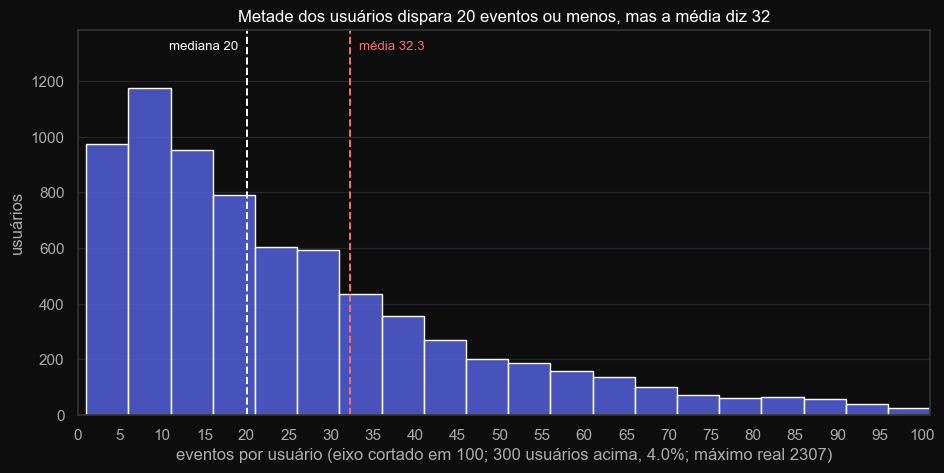

In [13]:
# -----------------------------------------------------------------------------
# 2.1 Distribuição de eventos por usuário
# -----------------------------------------------------------------------------
# Bin de 5 eventos, sem suavizar nada. Se houver furo na base ele aparece como zero
# no gráfico.
#
# Os bins começam em 1 e não em 0. Começando em 0, o primeiro bin seria [0, 5) e
# conteria só os inteiros 1 a 4, enquanto todos os outros contêm cinco valores. A
# primeira barra ficaria estruturalmente curta por conter um valor a menos, e eu
# estaria comparando barras que não medem a mesma coisa.
#
# Eixo cortado em 100, motivo declarado: o máximo é 2.307, mas o percentil 95 está em
# 89. Sem o corte, a faixa onde o usuário comum vive fica espremida contra a esquerda
# para acomodar uma cauda rala, e o gráfico deixa de responder a pergunta.
#
# Duas linhas de referência, porque a distância entre elas é o assunto da célula. A
# mediana em branco é o usuário do meio; a média em vermelho é a medida que o enunciado
# pede e que eu vou contestar na conclusão.

CORTE_X = 100

acima = (por_usuario > CORTE_X).sum()
media = por_usuario.mean()
mediana = por_usuario.median()

# Os usuários acima do corte não aparecem no gráfico, então eles ficam aqui em número.
# Um corte de eixo declarado no rótulo e não sustentado por nenhuma célula é afirmação
# sem prova. O que decide se o corte esconde algo relevante não é quantos usuários ficam
# de fora, é quanto volume eles carregam.
cauda = por_usuario[por_usuario > CORTE_X]

print('usuários acima do corte:', len(cauda),
      '(', round(len(cauda) / len(por_usuario) * 100, 1), '% dos usuários )')
print('eventos que eles geram:', cauda.sum(),
      '(', round(cauda.sum() / eventos * 100, 1), '% dos eventos )')
print('média de eventos na cauda:', round(cauda.mean(), 1),
      '| no resto da base:', round(por_usuario[por_usuario <= CORTE_X].mean(), 1))

print('\ncomo esses usuários se distribuem:')
print(pd.cut(cauda, bins=[CORTE_X, 200, 500, 1000, por_usuario.max()]).value_counts().sort_index())
print()

plt.figure(figsize=(11, 5))

ax = sns.histplot(por_usuario, bins=range(1, CORTE_X + 6, 5), color=CORES[0])

# Folga no topo para os rótulos ficarem acima da barra mais alta em vez de abrirem
# um buraco nela com o próprio fundo.
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

ax.axvline(mediana, color='white', ls='--', lw=1.4)
ax.axvline(media, color=CORES[1], ls='--', lw=1.4)

# Rótulo da mediana à esquerda da linha e o da média à direita: com 12 eventos de
# distância entre as duas, os dois do mesmo lado ficariam colados um no outro.
topo = ax.get_ylim()[1]
ax.annotate('mediana %d' % mediana, xy=(mediana, topo * .95), xytext=(-6, 0),
            textcoords='offset points', fontsize=9.5, color='white', ha='right',
            bbox=dict(facecolor='#0d0d0d', edgecolor='none', pad=1.6))
ax.annotate('média %.1f' % media, xy=(media, topo * .95), xytext=(6, 0),
            textcoords='offset points', fontsize=9.5, color=CORES[1], ha='left',
            bbox=dict(facecolor='#0d0d0d', edgecolor='none', pad=1.6))

# Marca de 5 em 5. As marcas caem em múltiplos de 5 e as bordas dos bins em 1, 6, 11 e
# assim por diante, então há um deslocamento de uma unidade entre marca e borda. É
# preferível a alternativa: marcar 1, 6, 11 seria alinhado com as barras mas ilegível.
ax.set_xticks(range(0, CORTE_X + 1, 5))
ax.set_xlim(0, CORTE_X + 1)

ax.set_xlabel('eventos por usuário (eixo cortado em %d; %d usuários acima, %.1f%%; máximo real %d)'
              % (CORTE_X, acima, acima / len(por_usuario) * 100, por_usuario.max()))
ax.set_ylabel('usuários')

# A grade do `meu_estilo` é #222222 e some sobre o fundo #0d0d0d. Sem grade visível,
# ler a altura de uma barra vira estimativa.
ax.grid(axis='y', color='#242430', linewidth=.9)
ax.grid(axis='x', visible=False)
ax.set_axisbelow(True)

ax.set_title('Metade dos usuários dispara 20 eventos ou menos, mas a média diz 32')

plt.savefig('images/2_1_eventos_por_usuario.png')
plt.show()

**Conclusão 2.1 — o tamanho da base e por que a média não serve:**

A base tem 243.713 eventos e 7.551 usuários, o que dá uma média de 32,3 eventos por pessoa. Essa
é a resposta literal do enunciado, e é a que eu não vou usar.

A mediana é 20, ou seja 61% abaixo da média. O desvio padrão é 65,2, o dobro da própria média, e
isso já bastava para desconfiar antes de eu desenhar qualquer coisa. O número que fecha o
argumento é outro: a média de 32,3 fica acima de 69,8% dos usuários. Uma medida de centro que deixa
mais de dois terços das observações de um lado só não está descrevendo o centro.

O gráfico mostra por quê. A distribuição sobe até a faixa de 6 a 10 eventos, que é onde está o
pico, e cai de forma contínua a partir dali. Metade das pessoas fica entre 9 e 37 eventos, e 110
usuários (1,46% do total) dispararam um evento e não voltaram.

A cauda é o que puxa a média. Os 300 usuários acima de 100 eventos são 4,0% da base e geram
64.184 eventos, ou 26,3% de todo o volume. Eles disparam 213,9 eventos por pessoa, contra 24,8 do
resto da base, 8,6 vezes mais. O mais ativo de todos tem 2.307 eventos, 115 vezes a mediana.

Dentro da própria cauda o padrão se repete em vez de mudar: 224 dos 300 estão entre 100 e 200
eventos, 57 entre 200 e 500, 13 entre 500 e 1.000, e 6 acima disso. Cada faixa fica com cerca de
um quarto da anterior. Não aparece um aglomerado separado de usuário pesado, aparece a mesma
queda contínua esticada. Isso importa porque significa que eu estou olhando uma população só, e
não duas misturadas que pediriam análises separadas.

Sobre o corte do eixo em 100. Ele deixa de fora 4,0% dos usuários e 26,3% dos eventos, e a
distância entre essas duas porcentagens deixa claro que pergunta o gráfico consegue responder.
Como a pergunta desta seção se mede em pessoas, o corte preserva 96% da resposta. Se a pergunta
fosse de onde vem o volume, o mesmo corte esconderia um quarto dela e seria enganoso. Deixei as
duas contagens impressas acima do gráfico para o corte poder ser conferido em vez de aceito.

Fica anotado que 6 usuários passaram de mil eventos em 13 dias e 16 horas, o que dá 73 disparos
por dia sustentados, e o mais ativo chega a 168. O log não tem campo que diga se é uma pessoa ou
uma automação, então eu não afirmo nem uma coisa nem outra. Registro porque, se mais adiante
alguma comparação ficar sensível a essas seis pessoas, é melhor já saber que elas existem.

## 2.2 O período que os dados cobrem

> *Enunciado: "Qual é o período de tempo que os dados cobrem? Encontre as datas máxima e mínima e
> desenhe um histograma por data e hora. Você pode ter certeza de que possui os dados igualmente
> completos para todo o período?"*

In [14]:
# -----------------------------------------------------------------------------
# 2.2 O período que os dados cobrem
# -----------------------------------------------------------------------------
# Os extremos já apareceram como teste de sanidade quando eu converti o timestamp. Aqui
# eles deixam de ser teste e passam a ser resultado.
#
# A tabela tem duas contagens por dia, eventos e usuários únicos, porque um dia pode ter
# poucos eventos com muita gente ou o contrário, e só as duas juntas mostram se a coleta
# estava ligada.
#
# A coluna de horas cobertas existe por um motivo específico. O primeiro evento é de
# madrugada e o último é de noite, então o primeiro e o último dia não têm 24 horas. Se
# eu comparar volume bruto, essas duas pontas aparecem baixas por aritmética e não por
# falha de coleta, e eu posso acabar cortando um dia que estava bom.
#
# A correção é projetar cada dia para 24 horas, e eu deixo o resultado na MESMA unidade
# da coluna bruta em vez de em eventos por hora. Assim a comparação entre o valor bruto e
# o corrigido se lê direto na tabela, sem ninguém precisar multiplicar nada. A coluna tem
# uma propriedade que a torna fácil de conferir: nos dias completos ela repete o bruto, e
# só muda nas duas pontas, que é onde a correção faz falta.
#
# A coluna de eventos por usuário é a segunda medida, e ela é independente da primeira.
# Volume por hora responde quanto foi registrado; eventos por usuário responde quanto
# foi registrado de cada pessoa. Se as duas apontarem a mesma data, o corte deixa de
# depender de uma medida só.

inicio = logs['Date_time'].min()
fim = logs['Date_time'].max()

print('primeiro evento:', inicio)
print('último evento:  ', fim)
print('intervalo:', fim - inicio)
print('dias de calendário:', logs['Date'].nunique())

por_dia = logs.groupby('Date').agg(
    eventos=('Event_Name', 'size'),
    usuarios=('ID_exclusive', 'nunique'))

# Horas de fato cobertas em cada dia: o dia inteiro, exceto nas duas pontas, onde a
# coleta começa e termina no meio.
por_dia['horas'] = [
    (min(dia + pd.Timedelta(days=1), fim) - max(dia, inicio)).total_seconds() / 3600
    for dia in por_dia.index
]

por_dia['eventos_em_24h'] = (por_dia['eventos'] / por_dia['horas'] * 24).round().astype(int)
# Divido o volume JÁ CORRIGIDO pelas horas, e não o bruto. Nos dias parciais a
# contagem de usuários quase não sofre, porque quase todo mundo que ia aparecer
# aparece de qualquer forma, mas a contagem de eventos sofre. Usar o bruto aqui
# deixaria as duas colunas medindo com réguas diferentes na mesma tabela.
por_dia['eventos_por_usuario'] = (por_dia['eventos_em_24h'] / por_dia['usuarios']).round(1)
por_dia['% dos eventos'] = (por_dia['eventos'] / eventos * 100).round(2)

# Arredondo a coluna de horas só agora, depois de ela ter sido usada com a precisão
# cheia no cálculo acima. Um `.round(1)` no `display` inteiro achataria o percentual
# dos dias pequenos para 0,0 e esconderia justamente o que eu quero ver.
por_dia['horas'] = por_dia['horas'].round(1)

display(por_dia)

primeiro evento: 2019-07-25 04:43:36
último evento:   2019-08-07 21:15:17
intervalo: 13 days 16:31:41
dias de calendário: 14


,eventos,usuarios,horas,eventos_em_24h,eventos_por_usuario,% dos eventos
Date,,,,,,
2019-07-25,9,7,19.3,11,1.6,0.00
2019-07-26,31,22,24.0,31,1.4,0.01
2019-07-27,55,39,24.0,55,1.4,0.02
2019-07-28,105,69,24.0,105,1.5,0.04
2019-07-29,184,135,24.0,184,1.4,0.08
2019-07-30,412,296,24.0,412,1.4,0.17
2019-07-31,2030,924,24.0,2030,2.2,0.83
2019-08-01,36141,3703,24.0,36141,9.8,14.83
2019-08-02,35554,3647,24.0,35554,9.7,14.59


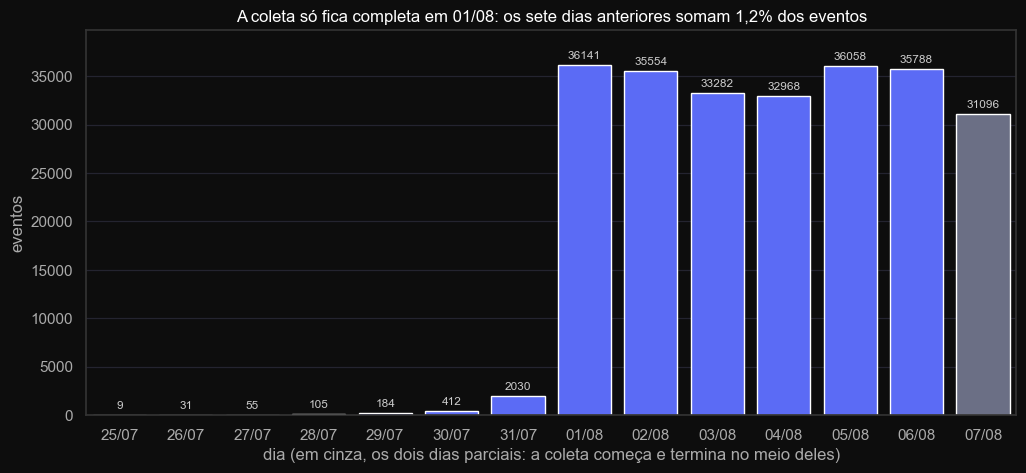

In [15]:
# -----------------------------------------------------------------------------
# 2.2 Volume por dia
# -----------------------------------------------------------------------------
# Barra e não linha. O eixo x tem catorze categorias discretas e a barra deixa o degrau
# visível, que é exatamente o que eu preciso enxergar. Linha sugeriria uma continuidade
# entre os dias que não existe no dado.
#
# Os dois dias parciais vão em cinza. Eles não são comparáveis aos outros em
# volume bruto, e pintá-los da mesma cor convidaria a comparação errada. O motivo fica
# escrito no rótulo do eixo, não só aqui no comentário.
#
# Pinto as barras depois de desenhadas em vez de usar `hue=` com `palette=`: a assinatura
# desses parâmetros mudou entre versões do seaborn e quebra em ambiente mais antigo.
# `order` implícito pela ordem da lista, que já vem ordenada pelo groupby.

CINZA = '#6b6f85'

rotulos = [d.strftime('%d/%m') for d in por_dia.index]
cor_da_barra = [CORES[0] if h >= 24 else CINZA for h in por_dia['horas']]

plt.figure(figsize=(12, 5))

ax = sns.barplot(x=rotulos, y=por_dia['eventos'].values, color=CORES[0])

for barra, cor in zip(ax.patches, cor_da_barra):
    barra.set_facecolor(cor)

# Rótulo em cada barra. Sem eles, as sete primeiras barras ficam desenhadas como zero,
# e nenhuma delas é zero. O laço percorre os containers porque o número deles varia com
# a versão do seaborn, e assim a célula funciona nos dois casos.
for c in ax.containers:
    ax.bar_label(c, fmt='%d', fontsize=8.5, color='#cccccc', padding=3)

ax.margins(y=.10)   # folga no topo para o rótulo da barra mais alta

ax.set_xlabel('dia (em cinza, os dois dias parciais: a coleta começa e termina no meio deles)')
ax.set_ylabel('eventos')
ax.grid(axis='y', color='#242430', linewidth=.9)
ax.grid(axis='x', visible=False)
ax.set_axisbelow(True)

ax.set_title('A coleta só fica completa em 01/08: os sete dias anteriores somam 1,2% dos eventos')

plt.savefig('images/2_2_eventos_por_dia.png')
plt.show()

**Conclusão 2.2 — catorze dias de calendário, sete de coleta:**

A base cobre de 25/07/2019 às 04:43:36 até 07/08/2019 às 21:15:17, ou seja 13 dias e 16 horas
distribuídos em 14 datas de calendário, sem nenhuma faltando. Essa é a parte fácil. A pergunta
seguinte do enunciado, se os dados estão igualmente completos em todo o período, tem resposta e
ela é não.

O degrau cai entre 31/07 e 01/08. São 2.030 eventos contra 36.141, um salto de 17,8 vezes de um
dia para o outro. Depois dele os sete dias finais ficam entre 32.968 e 36.141, uma variação de
9,6% que eu leio como estabilidade. Antes dele os sete primeiros dias sobem de 11 para 2.030,
quase dobrando a cada dia. Isso não é padrão de queda de coleta, que apareceria como buraco
irregular no meio do período. É subida contínua desde o primeiro registro. Os sete primeiros dias
somam 2.826 eventos, 1,16% da base.

A segunda medida da tabela concorda com a primeira e foi construída de forma independente dela.
Eventos por usuário fica entre 1,3 e 1,5 nos seis primeiros dias, sobe para 2,2 em 31/07 e passa a
ficar entre 8,5 e 9,8 nos sete dias finais. O volume mede quanto o log recebeu no total; eventos
por usuário mede quanto ele recebeu de cada pessoa. As duas apontam 01/08, então a data não
depende de qual delas eu escolher olhar. O que causou o período fraco eu não sei dizer:
instrumentação parcial e uso inicial baixo produzem a mesma tabela, e não existe coluna aqui que
separe as duas hipóteses. Para a decisão isso não muda nada, porque nos dois casos o período
inicial não é comparável ao resto.

A coluna projetada para 24 horas evitou um erro concreto. O dia 07/08 tem 31.096 eventos, e esse
número fica abaixo do menor dos outros seis dias bons, que é 32.968. Projetado para as 24 horas
que ele não teve, ele dá 35.112 e passa a cair dentro da faixa. A queda aparente é a coleta ter
terminado às 21:15. Sem essa coluna eu teria um argumento para cortar também o último dia, e
estaria jogando fora 12,76% dos eventos por aritmética de relógio.

Onde cortar exatamente, com que regra, e quanto isso custa em eventos e em usuários é o que eu
faço a seguir. Prefiro que esses números saiam do critério aplicado em código a escrevê-los aqui a
partir de uma conta que ninguém vê.

## 2.3 O corte dos dados incompletos e o que eu perdi

> *Enunciado: "Encontre o momento em que os dados começam a ser completos e ignore a seção anterior.
> Você perdeu muitos eventos e usuários ao excluir os dados mais antigos?"*

A parte que o enunciado não pede, e sem a qual o corte vira arbitrariedade, é escrever a **regra**
antes de aplicar. Corte escolhido a olho no gráfico é corte que eu não sei defender numa revisão.

In [16]:
# -----------------------------------------------------------------------------
# 2.3 O corte dos dados incompletos
# -----------------------------------------------------------------------------
# O CRITÉRIO, escrito antes de ser aplicado: considero completo o primeiro dia a partir
# do qual o volume corrigido alcança uma fração mínima da mediana da janela que começa
# nele, e se mantém acima dessa fração até o fim da base.
#
# A "fração mínima da mediana" é o quanto eu exijo de um dia para ele contar como
# completo. Com 0,5 eu estou exigindo que o dia tenha pelo menos metade do volume
# mediano dos dias dali em diante. É o único parâmetro do critério, e logo abaixo eu
# testo se a resposta depende dele.
#
# As duas condições fazem trabalho diferente. A primeira exige que o dia alcance o
# patamar. A segunda, o "e se mantém", impede que um pico isolado no meio de um período
# ruim seja confundido com o início da coleta boa. Sem ela, um único dia bom no meio do
# lixo passaria no teste.
#
# A função não recebe data nenhuma. Ela varre a série e devolve a data, para o resultado
# sair do critério e não da minha leitura do gráfico.
#
# Rodo a mesma função nas DUAS colunas que a tabela anterior produziu. `eventos_em_24h`
# mede quanto o log recebeu no total naquele dia; `eventos_por_usuario` mede quanto ele
# recebeu de cada pessoa. São medidas independentes uma da outra, e se as duas
# devolverem a mesma data, o corte não depende de qual delas eu escolhi olhar.

def primeiro_dia_completo(serie, fracao_minima):
    """Primeiro dia a partir do qual a série fica acima de `fracao_minima` vezes a
    mediana da janela que começa nele, e assim permanece até o fim."""
    for i, dia in enumerate(serie.index):
        janela = serie.iloc[i:]
        if (janela >= fracao_minima * janela.median()).all():
            return dia
    return None


FRACAO_MINIMA = 0.5

corte_por_volume = primeiro_dia_completo(por_dia['eventos_em_24h'], FRACAO_MINIMA)
corte_por_usuario = primeiro_dia_completo(por_dia['eventos_por_usuario'], FRACAO_MINIMA)

print('exigência: o dia precisa alcançar', int(FRACAO_MINIMA * 100),
    '% da mediana dos dias dali em diante')
print()
print('data escolhida olhando eventos_em_24h:     ', corte_por_volume.date())
print('data escolhida olhando eventos_por_usuario:', corte_por_usuario.date())
print('as duas medidas concordam:', corte_por_volume == corte_por_usuario)

corte = corte_por_volume

# Robustez. Se a data mudar conforme a exigência, o corte é frágil e eu preciso dizer
# isso. Se não mudar, a escolha do 0,5 deixa de importar e uma decisão arbitrária vira
# evidência. Foi o que os quatro cortes de rua movimentada mostraram no Sprint 10.
fracoes_testadas = [.1, .2, .3, .4, .5, .6, .7, .8, .9]

robustez = pd.DataFrame({
    'eventos_em_24h': [primeiro_dia_completo(por_dia['eventos_em_24h'], f)
                    for f in fracoes_testadas],
    'eventos_por_usuario': [primeiro_dia_completo(por_dia['eventos_por_usuario'], f)
                            for f in fracoes_testadas],
}, index=pd.Index(fracoes_testadas, name='fração mínima da mediana'))

print('\ndata que cada exigência devolve, nas duas medidas:')

# COMO LER ESTA TABELA. Uma coluna que repete a mesma data em todas as linhas quer
# dizer que todas as exigências testadas caem dentro da faixa em que aquela medida
# consegue separar os dois períodos. A data não depende do número que eu escolhi, e é
# isso que eu quero ver. Quanto maior o contraste entre o período ruim e o bom, mais
# larga é essa faixa, e mais fácil é a data se repetir de ponta a ponta.
#
# Uma linha que foge da data escolhida quer dizer que aquela exigência caiu fora da
# faixa, e há dois modos de sair dela.
#
#   Frouxa demais: a exigência fica tão baixa que os próprios dias ruins a satisfazem,
#   porque a mediana da janela está puxada para baixo por eles. O critério devolve uma
#   data cedo demais, no limite o primeiro dia da base.
#
#   Rigorosa demais: um dia bom não alcança a exigência e acaba reprovado junto com os
#   ruins. O critério devolve uma data tarde demais, descartando dia que prestava.
#
# As duas pontas dizem até onde cada medida aguenta ser esticada. Nenhuma delas
# invalida a data que se repete no meio da tabela, que é a que eu adoto.

display(robustez)

# Agora que a data existe, dá para medir a distância entre o último dia descartado e o
# primeiro mantido. Antes deste ponto do notebook eu não podia calcular isto, porque
# "mediana dos dias mantidos" depende de já se saber quais dias ficam.
mantidos = por_dia.loc[por_dia.index >= corte, 'eventos_em_24h']
descartados = por_dia.loc[por_dia.index < corte, 'eventos_em_24h']

print('\nmediana dos dias mantidos:', int(mantidos.median()))
print('último dia descartado, em % dessa mediana:',
      round(descartados.iloc[-1] / mantidos.median() * 100, 1))
print('primeiro dia mantido, em % dessa mediana:',
      round(mantidos.iloc[0] / mantidos.median() * 100, 1))

exigência: o dia precisa alcançar 50 % da mediana dos dias dali em diante

data escolhida olhando eventos_em_24h:      2019-08-01
data escolhida olhando eventos_por_usuario: 2019-08-01
as duas medidas concordam: True

data que cada exigência devolve, nas duas medidas:


,eventos_em_24h,eventos_por_usuario
fração mínima da mediana,,
0.1,2019-08-01,2019-07-25
0.2,2019-08-01,2019-07-25
0.3,2019-08-01,2019-08-01
0.4,2019-08-01,2019-08-01
0.5,2019-08-01,2019-08-01
0.6,2019-08-01,2019-08-01
0.7,2019-08-01,2019-08-01
0.8,2019-08-01,2019-08-01
0.9,2019-08-01,2019-08-01



mediana dos dias mantidos: 35554
último dia descartado, em % dessa mediana: 5.7
primeiro dia mantido, em % dessa mediana: 101.7


In [17]:
# -----------------------------------------------------------------------------
# 2.3b O que o corte custou
# -----------------------------------------------------------------------------
# NOME IMPORTANTE: `logs` continua sendo a base completa e `logs_ok` é a base cortada.
# Daqui para frente, toda análise usa `logs_ok`. Eu evitei reatribuir `logs` de
# propósito: rodar a célula duas vezes faria a base completa passar a apontar para a já
# cortada, e o preço do corte sairia zerado sem erro nenhum.
#
# A conta de usuários perdidos tem uma armadilha. Quem aparece no período descartado não
# é o mesmo que quem foi perdido: a maior parte dessas pessoas volta a aparecer depois do
# corte, e continua na base. Perdido é só quem NÃO tem nenhum evento no período mantido.
# Imprimo as duas contagens lado a lado para a diferença ficar à vista.

logs_ok = logs[logs['Date'] >= corte].reset_index(drop=True)

descartado = logs[logs['Date'] < corte]

usuarios_no_descarte = set(descartado['ID_exclusive'])
usuarios_mantidos = set(logs_ok['ID_exclusive'])
perdidos = usuarios_no_descarte - usuarios_mantidos

print('eventos removidos:', len(descartado),
      '(', round(len(descartado) / len(logs) * 100, 2), '% da base )')

print('\nusuários que apareciam no período descartado:', len(usuarios_no_descarte))
print('desses, continuam na base depois do corte:', len(usuarios_no_descarte & usuarios_mantidos))
print('usuários realmente perdidos:', len(perdidos),
      '(', round(len(perdidos) / logs['ID_exclusive'].nunique() * 100, 2), '% dos usuários )')

# Perda por grupo. Uma perda desigual entre os três braços desequilibraria a comparação
# entre eles antes de ela começar, e é melhor descobrir isso agora.
por_grupo = pd.DataFrame({
    'antes': logs.groupby('ID_group', observed=True)['ID_exclusive'].nunique(),
    'depois': logs_ok.groupby('ID_group', observed=True)['ID_exclusive'].nunique(),
})
por_grupo['perdidos'] = por_grupo['antes'] - por_grupo['depois']
por_grupo['% perdido'] = (por_grupo['perdidos'] / por_grupo['antes'] * 100).round(2)

print('\nusuários por grupo, antes e depois do corte:')
display(por_grupo)

print('\nbase final:', len(logs_ok), 'eventos e',
      logs_ok['ID_exclusive'].nunique(), 'usuários')

eventos removidos: 2826 ( 1.16 % da base )

usuários que apareciam no período descartado: 1451
desses, continuam na base depois do corte: 1434
usuários realmente perdidos: 17 ( 0.23 % dos usuários )

usuários por grupo, antes e depois do corte:


,antes,depois,perdidos,% perdido
ID_group,,,,
246,2489,2484,5,0.20
247,2520,2513,7,0.28
248,2542,2537,5,0.20



base final: 240887 eventos e 7534 usuários


**Conclusão 2.3 — o corte, em 01/08, custa quase nada:**

A regra: considero completo o primeiro dia a partir do qual o volume corrigido alcança pelo menos
50% da mediana dos dias que vêm depois dele, e se mantém acima disso até o fim da base. Aplicada
às duas medidas independentes (volume total por dia e volume por usuário), a data escolhida é a
mesma nas duas: 01/08/2019.

A data resiste à variação do critério. Testando a mesma regra com exigências de 10% a 90% da
mediana, ela se repete em 9 das 9 tentativas na medida de volume total e em 7 das 9 na medida por
usuário; só as duas exigências mais frouxas (10% e 20%) fogem para 25/07, porque nelas a mediana
da janela já mistura os dias ruins com os bons e a régua fica baixa demais para separar um do
outro. A data não depende da minha escolha de 50% porque o degrau entre os dois períodos é
grande: o último dia descartado (31/07) fica em 5,7% da mediana dos dias mantidos, e o primeiro
dia mantido (01/08) já fica em 101,7% dela.

O custo é pequeno. Cortar tudo antes de 01/08 remove 2.826 eventos, 1,16% da base. Em usuários o
efeito real é bem menor do que a contagem bruta sugere: 1.451 pessoas tinham eventos no período
descartado, mas 1.434 delas voltam a aparecer depois do corte, então a perda de fato é de 17
usuários, 0,23% do total. Essa perda se reparte de forma parecida nos três grupos (5 no 246,
0,20%; 7 no 247, 0,28%; 5 no 248, 0,20%), nenhum concentra a perda sozinho. A base que segue daqui
em diante, `logs_ok`, tem 240.887 eventos e 7.534 usuários.

## 2.4 Os três grupos experimentais

> *Enunciado: "Certifique-se de ter usuários de todos os três grupos experimentais."*

Faço o que o enunciado pede e acrescento uma verificação que ninguém pediu mas que, se falhar,
derruba a seção 4 inteira:  Tenho que ter em mente que **usuário não pode trocar de
grupo no meio do teste**. Se o log tiver o mesmo usuário nos dois braços, a comparação está
contaminada por ele.

In [18]:
# -----------------------------------------------------------------------------
# 2.4 Os três grupos experimentais
# -----------------------------------------------------------------------------
# Tudo aqui roda em `logs_ok`, a base já cortada. Contar grupo na base completa devolveria
# um número que inclui os dias que eu decidi não usar, e o tamanho dos grupos é o
# denominador de toda comparação entre eles.
#
# Três partes, e as duas últimas podem falhar, que é justamente o motivo de eu as escrever.
#
# PARTE 1: quantos usuários únicos em cada grupo, absoluto e em percentagem do total.
#
# PARTE 2: a régua que eu registrei em outras sprints, variação máxima de 1% no tamanho dos
# grupos. Régua sem definição é retórica, então eu declaro a minha: comparo o tamanho de
# cada grupo com o tamanho MÉDIO dos três, e o número que vai contra o 1% é o maior desvio
# em módulo. Imprimo junto a distância entre o maior e o menor grupo, que é a leitura
# alternativa, para o leitor não precisar aceitar a minha definição no escuro.
#
# PARTE 3: usuário em mais de um grupo. Aceito que usuário não troca
# de braço no meio do teste, e se acontecer aqui a comparação entre grupos está contando a
# mesma pessoa duas vezes, dos dois lados.
#
# Faço isso por dois caminhos independentes de propósito. O primeiro é uma invariante de
# uma linha: se ninguém troca de grupo, a soma dos usuários únicos dos três grupos TEM de
# bater com o total de usuários únicos da base. Se não bater, há gente contada mais de uma
# vez e eu descubro sem ter ido procurar. O segundo é o critério explícito, agrupando por
# usuário e contando grupos distintos, e é ele que diz quantos e quem, caso a invariante
# quebre. Um confirma o outro; se os dois discordarem, o erro é meu e não do dado.
#
# Se houver contaminação eu meço o tamanho dela e paro por aqui. Remover usuário é mexer no
# denominador de todas as comparações seguintes, e essa decisão vai discutida na conclusão,
# não escondida dentro de uma célula.

# --- PARTE 1 — tamanho de cada grupo ------------------------------------------
usuarios_ok = logs_ok['ID_exclusive'].nunique()

tamanho_grupos = pd.DataFrame({
    'usuarios': logs_ok.groupby('ID_group', observed=True)['ID_exclusive'].nunique(),
    'eventos': logs_ok.groupby('ID_group', observed=True).size(),
})
tamanho_grupos['% dos usuários'] = (tamanho_grupos['usuarios'] / usuarios_ok * 100).round(2)
tamanho_grupos['% dos eventos'] = (tamanho_grupos['eventos'] / len(logs_ok) * 100).round(2)

print('base cortada:', len(logs_ok), 'eventos e', usuarios_ok, 'usuários')
print('\nusuários e eventos por grupo:')
display(tamanho_grupos)

# --- PARTE 2 — a régua de 1% que aceito --------------------------------------
media_grupo = tamanho_grupos['usuarios'].mean()
desvio = (tamanho_grupos['usuarios'] - media_grupo) / media_grupo * 100

print('\ntamanho médio dos grupos:', round(media_grupo, 1), 'usuários')
print('desvio de cada grupo em relação a essa média, em %:')
print(desvio.round(2).to_string())

maior_desvio = desvio.abs().max()
spread = (tamanho_grupos['usuarios'].max() - tamanho_grupos['usuarios'].min()) / media_grupo * 100

print('\nmaior desvio em módulo:', round(maior_desvio, 2), '%')
print('distância entre o maior e o menor grupo:', round(spread, 2), '% da média',
      '(', tamanho_grupos['usuarios'].max() - tamanho_grupos['usuarios'].min(), 'usuários )')
print('passa na régua de 1%:', bool(maior_desvio <= 1))

# --- PARTE 3 — usuário em mais de um grupo ------------------------------------
# Caminho 1: a invariante. Soma das partes contra o todo.
soma_das_partes = tamanho_grupos['usuarios'].sum()

print('\nsoma dos usuários únicos dos três grupos:', soma_das_partes)
print('usuários únicos na base:                 ', usuarios_ok)
print('a soma bate com o total:', bool(soma_das_partes == usuarios_ok))

# Caminho 2: o critério explícito, que é o que me diz o tamanho do problema se houver.
grupos_por_usuario = logs_ok.groupby('ID_exclusive', observed=True)['ID_group'].nunique()
contaminados = grupos_por_usuario[grupos_por_usuario > 1].index

print('\nusuários em mais de um grupo:', len(contaminados),
      '(', round(len(contaminados) / usuarios_ok * 100, 2), '% dos usuários )')
print('eventos que pertencem a eles:', int(logs_ok['ID_exclusive'].isin(contaminados).sum()),
      '(', round(logs_ok['ID_exclusive'].isin(contaminados).mean() * 100, 2), '% dos eventos )')

# Os dois caminhos têm de dar a mesma resposta. Se discordarem, o problema está no meu
# código e não no dado, e é melhor descobrir aqui do que num denominador errado adiante.
print('\nos dois caminhos concordam:',
      bool((soma_das_partes == usuarios_ok) == (len(contaminados) == 0)))

base cortada: 240887 eventos e 7534 usuários

usuários e eventos por grupo:


,usuarios,eventos,% dos usuários,% dos eventos
ID_group,,,,
246,2484,79302,32.97,32.92
247,2513,77022,33.36,31.97
248,2537,84563,33.67,35.10



tamanho médio dos grupos: 2511.3 usuários
desvio de cada grupo em relação a essa média, em %:
ID_group
246   -1.09
247    0.07
248    1.02

maior desvio em módulo: 1.09 %
distância entre o maior e o menor grupo: 2.11 % da média ( 53 usuários )
passa na régua de 1%: False

soma dos usuários únicos dos três grupos: 7534
usuários únicos na base:                  7534
a soma bate com o total: True

usuários em mais de um grupo: 0 ( 0.0 % dos usuários )
eventos que pertencem a eles: 0 ( 0.0 % dos eventos )

os dois caminhos concordam: True


**Conclusão 2.4 — os três grupos existem e ninguém troca de braço:**

Os três braços estão na base cortada, que tem 240.887 eventos e 7.534 usuários. O 246 fica com
2.484 usuários (32,97%), o 247 com 2.513 (33,36%) e o 248 com 2.537 (33,67%). O enunciado pede só
isso, e a resposta é sim.

A régua que eu registrei anteriormente é variação máxima de 1% no tamanho dos grupos, e ela reprova.
O tamanho médio dos três é 2.511,3 usuários. Contra essa média, o 246 fica 1,09% abaixo, o 247
fica 0,07% acima e o 248 fica 1,02% acima. O maior desvio, 1,09%, passa do limite. Entre o maior e
o menor grupo há 53 usuários de diferença, 2,11% da média. Eu podia afrouxar a régua e dizer que
passou. Não faço isso, porque escrevi o número antes de olhar o dado e trocá-lo agora seria
escolher o critério pelo resultado. O que 53 usuários de folga tiram não é a validade da
comparação, é um pouco do poder dela. Isso pesa na hora de ler um resultado não significativo,
onde parte da explicação pode ser o tamanho da amostra e não a ausência de efeito.

Nenhum usuário aparece em mais de um grupo, e eu conferi isso por dois caminhos que não dependem
um do outro. O primeiro é aritmético: a soma dos usuários únicos dos três grupos dá 7.534, que é
exatamente o total de usuários únicos da base. Se alguém estivesse em dois braços, a soma passaria
do total. O segundo conta grupos distintos por usuário e devolve 0 pessoas com mais de um, 0,0%
dos usuários e 0,0% dos eventos. Os dois concordam, e a célula testa essa concordância em vez de
eu conferir a olho. Como não há nada a remover, os denominadores de qualquer comparação entre
braços são os três números do primeiro parágrafo.

A coluna de eventos mostra um desequilíbrio que a de usuários esconde. Em gente os braços ficam
dentro de 0,70 ponto percentual um do outro. Em eventos a distância chega a 3,13 pontos: o 248 tem
33,67% dos usuários e 35,10% dos eventos, enquanto o 247 tem 33,36% dos usuários e 31,97% dos
eventos. O usuário médio do 248 gera mais registro que o do 247. Como o 248 é o braço que recebeu
a fonte alterada, isso tanto pode ser efeito do que está sendo testado quanto diferença que já
existia entre os grupos antes de qualquer mudança. Não há coluna neste log que separe as duas
hipóteses e eu não vou escolher uma. O que dá para fixar é mais modesto: comparação feita sobre
contagem de eventos carrega essa assimetria dentro dela, comparação feita sobre contagem de
usuários não.

---



# 3. O funil de eventos



> **Enunciado:** Veja quais eventos estão nos diários e sua frequência de ocorrência,

+ classificados por frequência. Encontre o número de usuários que executaram cada uma dessas ações e

+ a proporção de usuários que executaram a ação pelo menos uma vez. Em que ordem você acha que as

+ ações ocorreram? Todas elas fazem parte de uma única sequência? Use o funil de eventos para

+ encontrar a parcela de usuários que passa de uma etapa para a próxima. Em qual fase você perde

+ mais usuários? Qual é a parcela de usuários que faz o caminho inteiro, do primeiro evento até o

+ pagamento?

## 3.1 Que eventos existem e com que frequência

> *Enunciado: "Veja quais eventos estão nos diários e sua frequência de ocorrência, classificados por
> frequência."*

eventos distintos no log: 5
linhas na base cortada:   240887

frequência de cada evento, do mais disparado ao menos:


,linhas,% das linhas,% acumulado
evento,,,
MainScreenAppear,117328,48.71,48.71
OffersScreenAppear,46333,19.23,67.94
CartScreenAppear,42303,17.56,85.50
PaymentScreenSuccessful,33918,14.08,99.58
Tutorial,1005,0.42,100.00


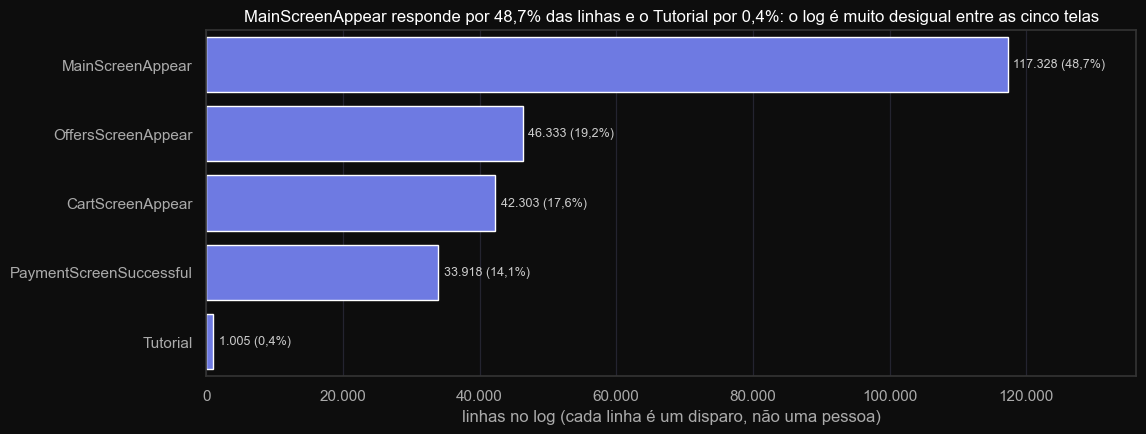

In [19]:
# -----------------------------------------------------------------------------
# 3.1 Que eventos existem e com que frequência
# -----------------------------------------------------------------------------
# Contagem de LINHAS por evento na base cortada, ordenada por frequência como o enunciado
# pede, com a coluna relativa ao lado. Acrescento o acumulado porque ele responde de relance
# uma pergunta que a coluna solta não responde: quanto do log está concentrado nos primeiros
# eventos da lista.
#
# O que esta contagem mede, e o que ela não mede. Cada linha é um disparo, e o mesmo usuário
# pode disparar o mesmo evento dezenas de vezes. Então esta tabela mede insistência, ou seja
# quanto de tráfego cada tela gerou, e não quantas pessoas passaram por ela. Um evento pode
# liderar aqui só porque quem o usa volta muito, e pode cair para o fim da lista mesmo tendo
# sido visto por quase todo mundo uma vez só. Enquanto eu não contar usuário único, esta
# ordem não autoriza conclusão nenhuma sobre qual tela vem antes de qual no caminho do
# usuário. Ela é matéria-prima para essa pergunta, não a resposta dela.

freq_eventos = pd.DataFrame({'linhas': logs_ok['Event_Name'].value_counts()})
freq_eventos['% das linhas'] = (freq_eventos['linhas'] / len(logs_ok) * 100).round(2)
freq_eventos['% acumulado'] = freq_eventos['% das linhas'].cumsum().round(2)
freq_eventos.index.name = 'evento'

print('eventos distintos no log:', logs_ok['Event_Name'].nunique())
print('linhas na base cortada:  ', len(logs_ok))
print('\nfrequência de cada evento, do mais disparado ao menos:')
display(freq_eventos)

# --- gráfico ------------------------------------------------------------------
# Barra HORIZONTAL: os nomes dos eventos são longos e no eixo x sairiam inclinados ou
# cortados. Deitada, cada nome ocupa uma linha e se lê sem esforço.
#
# `order=` explícito com o índice já ordenado. Sem ele o seaborn ordena pelo dtype da
# categoria, e como o rótulo cola por posição, os números saem grudados na barra errada.
# Foi isso que me mordeu no Sprint 10.
#
# `color=` único e não `palette=`: as cinco barras são a mesma grandeza medida em categorias
# diferentes, e pintar cada uma de uma cor sugeriria uma distinção que não existe no dado.

def milhar(n):
    """Separador de milhar com ponto"""
    return '{:,.0f}'.format(n).replace(',', '.')

ordem = freq_eventos.index.tolist()

# Rótulo com absoluto e relativo juntos
rotulos_barra = [
    '{} ({}%)'.format(milhar(n), '{:.1f}'.format(p).replace('.', ','))
    for n, p in zip(freq_eventos['linhas'], freq_eventos['% das linhas'])
]

plt.figure(figsize=(12, 4.5))

ax = sns.barplot(x=freq_eventos['linhas'].values, y=ordem, order=ordem, color=CORES[0])

ax.bar_label(ax.containers[0], labels=rotulos_barra, fontsize=9, color='#cccccc', padding=4)
ax.margins(x=.16)   # folga à direita para o rótulo da barra mais longa não sair do quadro

# Sem isto o eixo imprime 120000 em vez de 120.000.
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: milhar(v)))

ax.set_xlabel('linhas no log (cada linha é um disparo, não uma pessoa)')
ax.set_ylabel('')
ax.grid(axis='x', color='#242430', linewidth=.9)
ax.grid(axis='y', visible=False)
ax.set_axisbelow(True)

ax.set_title('MainScreenAppear responde por 48,7% das linhas e o Tutorial por 0,4%: '
            'o log é muito desigual entre as cinco telas')

plt.savefig('images/3_1_eventos_por_frequencia.png')
plt.show()

**Conclusão 3.1 — cinco eventos, e a ordem desta lista ainda não é a ordem do funil:**

Os eventos são cinco e a base cortada tem 240.887 linhas. O `MainScreenAppear` responde por
117.328 delas (48,71%), o `OffersScreenAppear` por 46.333 (19,23%), o `CartScreenAppear` por
42.303 (17,56%), o `PaymentScreenSuccessful` por 33.918 (14,08%) e o `Tutorial` por 1.005
(0,42%). A coluna do acumulado mostra que os quatro primeiros cobrem 99,58% do log. Essa é a
resposta literal do enunciado, e é metade do que a tabela tem para dizer.

Sobre o que esta contagem não autoriza. Cada linha é um disparo e não uma pessoa, e nada nesta
tabela separa uma tela vista por muita gente de uma tela revisitada por pouca. Que a repetição
exista está na própria tabela: o `MainScreenAppear` tem 117.328 linhas e a base inteira tem 7.534
usuários, então a mesma pessoa disparou aquela tela muitas vezes. O que a tabela mede é
insistência, ou seja quanto tráfego cada tela gerou, e não alcance, que seria quanta gente passou
por ela. Uma tela pode liderar aqui por causa de poucas pessoas que voltam muito, e outra pode
ficar no fim da lista por ser vista uma vez só e nunca repetida. As duas leituras cabem nos mesmos
números, e nada nesta célula escolhe entre elas.


O `Tutorial` é o candidato natural ao segundo caso, porque pelo nome é tela de passagem e uma
contagem de disparos castiga justamente quem não repete. Isso é o que eu espero dele, não o que
eu medi, e repetição do `Tutorial` por usuário não foi contada até aqui. O que a contagem resolve
sozinha é outra coisa. Cada pessoa que viu a tela gerou pelo menos uma linha, portanto as 1.005
linhas do `Tutorial` são um teto para quantas pessoas passaram por ele, e a base tem 7.534
usuários. Qualquer que seja o comportamento por trás, o `Tutorial` não alcançou quase todo mundo,
porque não haveria linha suficiente para isso. Esse é o único alcance que a contagem de linha
entrega de graça: ela não diz quantas pessoas viram um evento, mas põe um limite superior em
quantas podem ter visto.

A armadilha desta seção é a própria ordem que saiu. `MainScreenAppear`, `OffersScreenAppear`,
`CartScreenAppear` e `PaymentScreenSuccessful` é exatamente a sequência que se esperaria de uma
loja, e isso convida a ler a tabela como se ela já fosse um funil. Se eu cedesse, tomaria a queda
de linhas de uma tela para a seguinte como taxa de conversão. Não é conversão, é razão entre
disparos, e nada nesta contagem garante que quem gerou a linha de baixo tenha gerado a de cima. A
própria tabela mostra o custo do erro: logo acima do `Tutorial` está o `PaymentScreenSuccessful`,
de modo que ler esta lista como funil colocaria uma etapa depois da compra concluída. Posição na
lista de frequência não é posição no funil.

O que a célula entrega é o inventário dos eventos e o peso de cada um no volume do log. Para
falar em etapa faltam duas coisas. Uma é contar usuário único por evento, que troca disparo por
pessoa e converte o teto do parágrafo acima em número exato. A outra é uma regra para o empate de
segundo, e ele já está visível na amostra das dez primeiras linhas impressa na 1.1: ali as linhas
2 e 3 são o mesmo usuário com pagamento e carrinho carimbados no mesmo segundo, e as linhas 4 e 5
são outro usuário com o pagamento um segundo antes do carrinho. Enquanto essas duas coisas não
existirem, esta tabela é matéria-prima da ordem do funil e não a ordem dele.

## 3.2 Usuários por evento

> *Enunciado: "Encontre o número de usuários que executaram cada uma dessas ações e a proporção de
> usuários que executaram a ação pelo menos uma vez."*

In [20]:
# -----------------------------------------------------------------------------
# 3.2 Usuários por evento
# -----------------------------------------------------------------------------
# Aqui eu troco disparo por pessoa. A contagem anterior media quanto tráfego cada tela gerou;
# esta mede quanta gente passou por ela pelo menos uma vez, que é o que o enunciado pede.
#
# O denominador é o total de usuários DEPOIS do corte, não o da base bruta, e eu imprimo ele
# antes da tabela. Proporção com denominador escondido é número que ninguém consegue conferir
# depois, e a diferença entre as duas bases aqui não é decorativa: são 7.534 contra 7.551.
#
# A terceira coluna, linhas por usuário, sai do cruzamento das duas contagens e é a que separa
# alcance de insistência numa medida só. Ela é uma razão entre dois números da mesma tabela,
# então o leitor confere dividindo duas colunas. Duas telas podem ter alcance parecido e ritmos
# completamente diferentes, e é isso que essa coluna mostra.
#
# Comparo as duas ordens com um teste que imprime True ou False, em vez de eu olhar as duas
# listas e afirmar que são iguais. Se coincidirem, isso não é desinteressante: significa que a
# tela mais disparada também é a mais alcançada, e que a ordenação da seção anterior não estava
# sendo produzida só por quem repete muito.

total_usuarios = logs_ok['ID_exclusive'].nunique()

alcance = pd.DataFrame({
    'usuários': logs_ok.groupby('Event_Name', observed=True)['ID_exclusive'].nunique()
})
alcance['% dos usuários']     = (alcance['usuários'] / total_usuarios * 100).round(2)
alcance['linhas']             = logs_ok['Event_Name'].value_counts()
alcance['linhas por usuário'] = (alcance['linhas'] / alcance['usuários']).round(1)
alcance = alcance.sort_values('usuários', ascending=False)
alcance.index.name = 'evento'

print('denominador declarado:', milhar(total_usuarios), 'usuários na base cortada')
print('(total depois do corte, não o da base bruta)\n')
display(alcance)

# Comparação das duas ordens por teste, não a olho.
ordem_frequencia = logs_ok['Event_Name'].value_counts().index.tolist()
ordem_alcance    = alcance.index.tolist()

print('ordem por frequência de linha:', ' > '.join(ordem_frequencia))
print('ordem por alcance em usuários:', ' > '.join(ordem_alcance))
print('as duas ordens coincidem:', ordem_frequencia == ordem_alcance)

# Quem não passou pela tela mais alcançada de todas. Se ela fosse porta de entrada obrigatória,
# este número teria de ser zero.
sem_principal = total_usuarios - alcance['usuários'].iloc[0]
print('\nusuários que nunca dispararam %s: %s (%.2f%% dos %s)'
    % (ordem_alcance[0], milhar(sem_principal),
         sem_principal / total_usuarios * 100, milhar(total_usuarios)))

denominador declarado: 7.534 usuários na base cortada
(total depois do corte, não o da base bruta)



,usuários,% dos usuários,linhas,linhas por usuário
evento,,,,
MainScreenAppear,7419,98.47,117328,15.8
OffersScreenAppear,4593,60.96,46333,10.1
CartScreenAppear,3734,49.56,42303,11.3
PaymentScreenSuccessful,3539,46.97,33918,9.6
Tutorial,840,11.15,1005,1.2


ordem por frequência de linha: MainScreenAppear > OffersScreenAppear > CartScreenAppear > PaymentScreenSuccessful > Tutorial
ordem por alcance em usuários: MainScreenAppear > OffersScreenAppear > CartScreenAppear > PaymentScreenSuccessful > Tutorial
as duas ordens coincidem: True

usuários que nunca dispararam MainScreenAppear: 115 (1.53% dos 7.534)


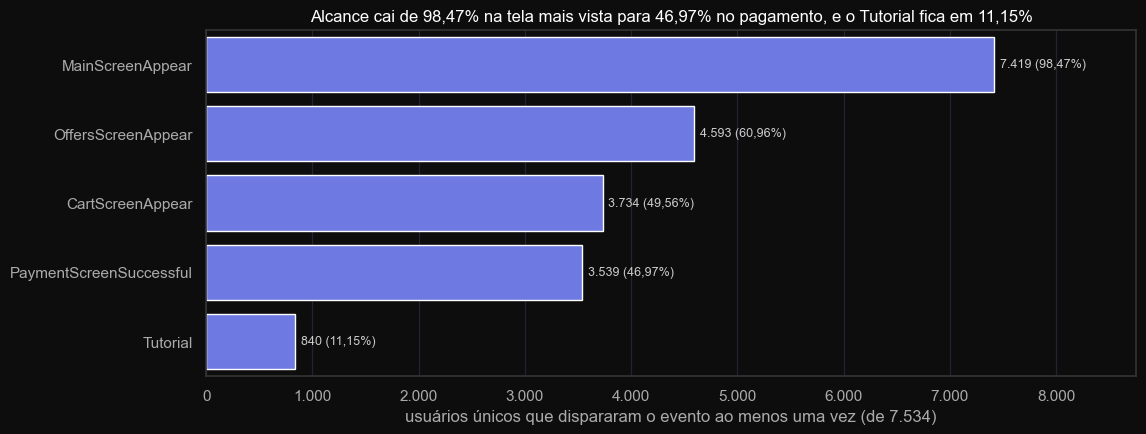

In [21]:
# Sobre o gráfico, o critério para manter ou apagar. A dúvida legítima é se esta tabela é a
# anterior noutra escala. O que decide não é a ordem, é o formato da repartição: em linhas a
# tela principal fica em 48,71% e o pagamento em 14,08%, e se os percentuais de pessoas tiverem
# esse mesmo perfil o gráfico é redundante. Eu espero que ele venha mais achatado, porque uma
# pessoa conta uma vez por tela enquanto os disparos se acumulam, e nesse caso a informação é
# nova e o desenho se justifica. Confiro no output antes de decidir manter.
#
# O que eu não desenho é as duas séries no mesmo eixo. O percentual de linhas soma 100 entre os
# eventos e o percentual de usuários não soma, porque a mesma pessoa conta em várias telas.
# Colocar as duas na mesma barra convidaria a comparar grandezas com denominadores diferentes.
# A comparação entre elas fica na coluna de linhas por usuário, que é uma taxa e não sofre disso.
#
# `milhar()` eu reaproveito em vez de redefinir.

# --- gráfico ------------------------------------------------------------------
# Mesma linguagem visual da célula anterior: barra horizontal, ordem explícita em `order=`,
# cor única porque é a mesma grandeza em categorias diferentes, rótulo com absoluto e relativo.

def pct_br(p):
    """Percentual com vírgula decimal."""
    return '{:.2f}'.format(p).replace('.', ',')

ordem = alcance.index.tolist()

rotulos_barra = [
    '{} ({}%)'.format(milhar(n), pct_br(p))
    for n, p in zip(alcance['usuários'], alcance['% dos usuários'])
]

plt.figure(figsize=(12, 4.5))

ax = sns.barplot(x=alcance['usuários'].values, y=ordem, order=ordem, color=CORES[0])

ax.bar_label(ax.containers[0], labels=rotulos_barra, fontsize=9, color='#cccccc', padding=4)
ax.margins(x=.18)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: milhar(v)))

ax.set_xlabel('usuários únicos que dispararam o evento ao menos uma vez (de %s)' % milhar(total_usuarios))
ax.set_ylabel('')
ax.grid(axis='x', color='#242430', linewidth=.9)
ax.grid(axis='y', visible=False)
ax.set_axisbelow(True)

ax.set_title('Alcance cai de {}% na tela mais vista para {}% no pagamento, e o Tutorial fica em {}%'
            .format(pct_br(alcance['% dos usuários'].iloc[0]),
                    pct_br(alcance.loc['PaymentScreenSuccessful', '% dos usuários']),
                    pct_br(alcance.loc['Tutorial', '% dos usuários'])))

plt.savefig('images/3_2_usuarios_por_evento.png')
plt.show()


**Conclusão 3.2 — alcance não reordena as telas, mas achata a distância entre elas:**

Sobre os 7.534 usuários da base cortada, que é o denominador impresso acima da tabela, o
`MainScreenAppear` alcança 7.419 pessoas (98,47%), o `OffersScreenAppear` 4.593 (60,96%), o
`CartScreenAppear` 3.734 (49,56%), o `PaymentScreenSuccessful` 3.539 (46,97%) e o `Tutorial` 840
(11,15%). Essa é a resposta do enunciado. O que interessa depois dela é se contar gente em vez de
disparo muda a leitura. Muda uma coisa e não muda outra.

Não muda a ordem. As duas listas saem idênticas nas cinco posições, e a célula testa isso em vez
de eu comparar a olho. Com isso fecha uma dúvida que a seção anterior deixou aberta, onde eu
escrevi que uma tela poderia liderar a contagem de linhas por causa de poucas pessoas que voltam
muito. Se fosse esse o caso, a ordem por pessoas teria mudado. Não mudou, então a hierarquia não
vinha de quem repete.

Muda o formato, e muito. Em linhas a repartição é 48,71%, 19,23%, 17,56%, 14,08% e 0,42%, com a
tela principal levando quase metade do log sozinha. Em pessoas ela é 98,47%, 60,96%, 49,56%,
46,97% e 11,15%. Os cinco percentuais de pessoas não somam 100 e não deveriam somar: cada usuário
conta uma vez em cada tela por que passou, de modo que os conjuntos se sobrepõem. Era exatamente
isso que a contagem de linhas escondia.

A coluna de linhas por usuário mede o que a seção anterior só conseguiu supor. Lá ficou escrito,
com todas as letras, que o `Tutorial` ser tela de passagem era expectativa minha e não medida.
Agora é medida: 1,2 linhas por usuário no `Tutorial`, contra 15,8 na tela principal. Quem abre o
tutorial vê e segue, enquanto a tela principal é disparada 15,8 vezes em média por quem passa por
ela. Também se confirma o teto que eu afirmei lá. As 1.005 linhas do `Tutorial` limitavam o
alcance dele a no máximo 1.005 pessoas, e o alcance real é 840.

Essa mesma coluna mostra uma inversão que o alcance sozinho esconde. O carrinho tem 11,3 linhas
por usuário e as ofertas têm 10,1, embora o carrinho alcance menos gente. Quem chega ao carrinho
volta a ele mais do que quem passa pelas ofertas volta às ofertas. Não existe coluna neste log que
explique por quê, então eu registro o fato sem escolher explicação para ele.

Um número pequeno merece destaque porque derruba uma suposição grande: 115 usuários (1,53%) nunca
dispararam o `MainScreenAppear`. A conta fecha, porque 7.419 + 115 dá exatamente os 7.534 da
base. Se a tela principal fosse porta de entrada obrigatória do aplicativo, esse número teria de
ser zero. Ele não é. Existe gente neste log que aparece sem nunca ter registrado a tela mais vista
de todas, e isso já me impede de tratar a sequência das telas como caminho único.

Falta dizer o que esta tabela continua não autorizando. Os degraus são convidativos, de 98,47%
para 60,96%, depois para 49,56% e depois para 46,97%, com quase toda a perda concentrada no
primeiro salto. Chamar isso de conversão seria repetir o erro da seção anterior num nível acima. A
tabela dá o alcance de cada evento isoladamente, e não diz que os 3.539 do pagamento estão dentro
dos 3.734 do carrinho. Dois eventos podem ter 49,56% e 46,97% sem nenhum aninhamento entre eles, e
os percentuais passando de 100 na soma mostram que sobreposição é a regra aqui. Para falar em
perda de uma etapa para a seguinte é preciso contar quem tem as duas, não subtrair dois totais
que foram medidos separadamente.

## 3.3 A ordem das etapas

> *Enunciado: "Em que ordem você acha que as ações ocorreram? Todas elas fazem parte de uma única
> sequência?"*

"Acha" não basta. O nome das telas sugere uma ordem, o alcance da 3.2 sugere outra, e o próprio
arquivo já mostrou na 1.1 uma linha de pagamento registrada antes da linha de carrinho, no mesmo
usuário. As três leituras precisam ser confrontadas antes de eu fixar o funil.

In [22]:
# -----------------------------------------------------------------------------
# 3.3 A ordem das etapas — evidências 1 e 2
# -----------------------------------------------------------------------------
# Três evidências independentes, e só depois a decisão. Esta célula registra as duas primeiras.
#
# EVIDÊNCIA 1 é o nome das telas, leitura puramente semântica. Escrevo como lista literal antes
# de olhar qualquer cronologia, justamente para o dado poder me desmentir depois. Se eu olhasse
# os números primeiro, não teria como saber se cheguei à ordem por raciocínio ou se copiei o
# que a tabela já mostrava.
#
# EVIDÊNCIA 2 é o alcance em usuários únicos. Num funil que só perde gente, a etapa anterior
# alcança pelo menos tanta gente quanto a seguinte, porque quem chegou à segunda passou pela
# primeira. Ordenar por alcance decrescente dá uma ordem candidata.
#
# O que essas duas evidências NÃO são. A primeira é opinião informada pelo nome do evento, e
# nome de evento é escolha de quem instrumentou o aplicativo, não é comportamento. A segunda é
# ordem por tamanho, e tamanho decrescente é condição necessária de um funil, não suficiente:
# três conjuntos podem encolher sem que um contenha o outro. As duas concordarem não prova
# nada sozinho, e é por isso que existe uma terceira.

ordem_semantica = ['MainScreenAppear',         # abre o aplicativo
                'OffersScreenAppear',       # olha as ofertas
                'CartScreenAppear',         # põe no carrinho
                'PaymentScreenSuccessful']  # paga

fora_por_semantica = ['Tutorial']    # pelo nome, introdução e não etapa de compra

print('EVIDÊNCIA 1, o nome das telas:')
print('   ', ' > '.join(ordem_semantica))
print('    fora da sequência, pelo nome:', ', '.join(fora_por_semantica))

ordem_por_alcance = [e for e in alcance.index if e not in fora_por_semantica]

print('\nEVIDÊNCIA 2, o alcance em usuários únicos:')
display(alcance.loc[ordem_por_alcance])

print('as duas primeiras evidências concordam:', bool(ordem_semantica == ordem_por_alcance))

EVIDÊNCIA 1, o nome das telas:
    MainScreenAppear > OffersScreenAppear > CartScreenAppear > PaymentScreenSuccessful
    fora da sequência, pelo nome: Tutorial

EVIDÊNCIA 2, o alcance em usuários únicos:


,usuários,% dos usuários,linhas,linhas por usuário
evento,,,,
MainScreenAppear,7419,98.47,117328,15.8
OffersScreenAppear,4593,60.96,46333,10.1
CartScreenAppear,3734,49.56,42303,11.3
PaymentScreenSuccessful,3539,46.97,33918,9.6


as duas primeiras evidências concordam: True


In [23]:
# -----------------------------------------------------------------------------
# 3.3b A ordem das etapas — evidência 3, a cronologia
# -----------------------------------------------------------------------------
# Aqui eu paro de argumentar e vou ao relógio. `pivot_table` com agregação de mínimo dá o
# PRIMEIRO instante de cada evento dentro de cada usuário, que é a receita da minha nota de
# funil. Depois comparo os eventos dois a dois: entre quem tem os dois, em que fração o
# primeiro A veio antes do primeiro B.
#
# A REGRA DE DESEMPATE, escrita antes de eu ver o resultado, porque decidir depois é escolher
# o critério pelo resultado:
#
#   1. Empate é diferença de zero segundos, e eu NÃO desempato pela ordem das linhas do arquivo.
#      O arquivo está ordenado por tempo, então dentro do mesmo segundo a ordem das linhas é a
#      do coletor gravando, não a do usuário agindo. Usá-la seria inventar precisão inexistente.
#   2. Só considero a ordem estabelecida quando A vem antes de B em pelo menos 90% dos casos.
#      A folga cobre o ruído de quem volta dias depois e embaralha o primeiro instante.
#   3. Se o empate sozinho passar de 25%, o veredito não é "sem ordem", é "indeterminável": os
#      dois eventos disparam juntos e um carimbo em segundos não separa. As duas conclusões são
#      diferentes e não podem virar uma só.
#
# Os pares vão escritos um a um em vez de gerados, porque são seis e a lista explícita mostra
# exatamente o que foi testado. Os dois limites são constantes nomeadas para ficarem auditáveis
# em vez de números soltos dentro de um `if`.

LIMITE_ORDEM = 90     # % mínimo de A antes de B para eu aceitar que a ordem existe
LIMITE_EMPATE = 25    # acima disso o par é indeterminável, não desordenado

PARES = [('MainScreenAppear',   'OffersScreenAppear'),
        ('MainScreenAppear',   'CartScreenAppear'),
        ('MainScreenAppear',   'PaymentScreenSuccessful'),
        ('OffersScreenAppear', 'CartScreenAppear'),
        ('OffersScreenAppear', 'PaymentScreenSuccessful'),
        ('CartScreenAppear',   'PaymentScreenSuccessful')]

primeiro_de_cada = logs_ok.pivot_table(index='ID_exclusive', columns='Event_Name',
                                    values='Timestamp_unix', aggfunc='min', observed=True)


def diferenca_do_par(primeiros, a, b):
    """Segundos entre o primeiro `a` e o primeiro `b` de cada usuário que tem os dois.
    Negativo quer dizer que `a` veio antes."""
    sub = primeiros[[a, b]].dropna()
    return sub[a] - sub[b]


def curto(evento):
    """Nome do evento sem o sufixo, só para o rótulo caber na largura da tela."""
    return evento.replace('ScreenAppear', '').replace('ScreenSuccessful', '')


cronologia = pd.DataFrame({
    'usuários com os dois': [len(diferenca_do_par(primeiro_de_cada, a, b)) for a, b in PARES],
    '% A antes': [round((diferenca_do_par(primeiro_de_cada, a, b) < 0).mean() * 100, 2)
                for a, b in PARES],
    '% empate': [round((diferenca_do_par(primeiro_de_cada, a, b) == 0).mean() * 100, 2)
                for a, b in PARES],
    '% B antes': [round((diferenca_do_par(primeiro_de_cada, a, b) > 0).mean() * 100, 2)
                for a, b in PARES],
}, index=pd.Index([curto(a) + ' antes de ' + curto(b) for a, b in PARES], name='par'))

cronologia['veredito'] = ['indeterminável: o relógio não separa' if empate >= LIMITE_EMPATE
                        else 'ordem estabelecida' if antes >= LIMITE_ORDEM
                        else 'sem ordem: intercambiáveis'
                        for antes, empate in zip(cronologia['% A antes'],
                                                cronologia['% empate'])]

print('empate é diferença de zero segundos, e eu não desempato pela ordem das linhas')
print('ordem estabelecida exige', LIMITE_ORDEM, '% de A antes de B')
print('empate acima de', LIMITE_EMPATE, '% torna o par indeterminável, não desordenado')
print()
display(cronologia)

empate é diferença de zero segundos, e eu não desempato pela ordem das linhas
ordem estabelecida exige 90 % de A antes de B
empate acima de 25 % torna o par indeterminável, não desordenado



,usuários com os dois,% A antes,% empate,% B antes,veredito
par,,,,,
Main antes de Offers,4482,93.73,0.02,6.25,ordem estabelecida
Main antes de Cart,3635,94.20,0.22,5.58,ordem estabelecida
Main antes de Payment,3441,94.97,0.03,5.00,ordem estabelecida
Offers antes de Cart,3679,54.91,0.95,44.14,sem ordem: intercambiáveis
Offers antes de Payment,3532,61.95,0.51,37.54,sem ordem: intercambiáveis
Cart antes de Payment,3534,26.97,49.77,23.26,indeterminável: o relógio não separa


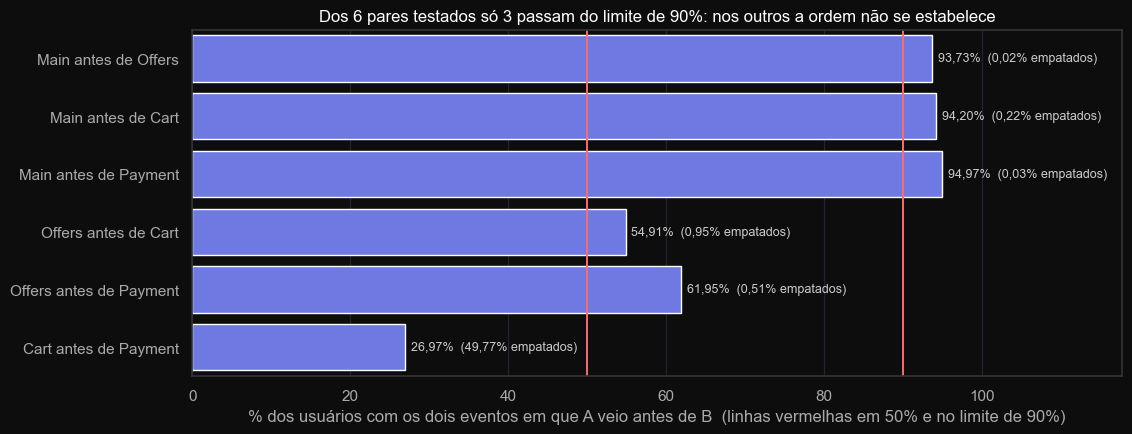

In [24]:
# --- gráfico ------------------------------------------------------------------
# Mesma forma das outras seções: barra horizontal, ordem explícita em `order=`, cor única,
# rótulo pelo `bar_label`. As duas retas vermelhas dizem como ler: a de 50% é onde mora "sem
# ordem", a outra é o limite que eu declarei acima. O título é montado a partir do resultado

ordenados = int((cronologia['veredito'] == 'ordem estabelecida').sum())

ordem_das_barras = cronologia.index.tolist()

rotulos_barra = [pct_br(antes) + '%  (' + pct_br(empate) + '% empatados)'
                for antes, empate in zip(cronologia['% A antes'], cronologia['% empate'])]

plt.figure(figsize=(12, 4.5))

ax = sns.barplot(x=cronologia['% A antes'].values, y=ordem_das_barras,
                order=ordem_das_barras, color=CORES[0])

ax.bar_label(ax.containers[0], labels=rotulos_barra, fontsize=9, color='#cccccc', padding=4)
ax.margins(x=.24)

ax.axvline(50, color=CORES[1], lw=1.4)
ax.axvline(LIMITE_ORDEM, color=CORES[1], lw=1.4)

ax.set_xlabel('% dos usuários com os dois eventos em que A veio antes de B  '
            '(linhas vermelhas em 50% e no limite de {}%)'.format(LIMITE_ORDEM))
ax.set_ylabel('')
ax.grid(axis='x', color='#242430', linewidth=.9)
ax.grid(axis='y', visible=False)
ax.set_axisbelow(True)

ax.set_title('Dos {} pares testados só {} passam do limite de {}%: '
            'nos outros a ordem não se estabelece'
            .format(len(cronologia), ordenados, LIMITE_ORDEM))

plt.savefig('images/3_3_ordem_dos_pares.png')
plt.show()

In [25]:
# -----------------------------------------------------------------------------
# 3.3c A ordem das etapas — por que um par falha não é por que o outro falha
# -----------------------------------------------------------------------------
# A célula anterior separou "sem ordem" de "indeterminável" por um limite que eu escolhi. Esta
# testa se a separação se sustenta em medidas independentes, porque veredito que só existe por
# causa do meu limite não vale muito.
#
# TESTE 1, a distância no tempo. Se dois eventos disparam juntos, a diferença entre os dois
# primeiros instantes fica em zero ou um segundo para a maioria, e o problema é resolução do
# relógio. Se eles são bem separados no tempo e mesmo assim não têm direção fixa, a desordem é
# real. A mediana é a medida certa aqui, porque quem volta dias depois joga a média para as
# alturas sem descrever ninguém, e eu imprimo as duas lado a lado para isso ficar visível.
#
# TESTE 2, a robustez contra o método. Pegar o primeiro instante na vida inteira do usuário
# mistura visitas: o primeiro carrinho de alguém pode ser de uma visita e o primeiro "ofertas"
# de outra, sem que a ordem dentro de cada visita seja essa. Refaço a comparação só com quem
# tem toda a história dentro de uma hora, que é a melhor aproximação de visita única que este
# log permite, e testo se algum par mudaria de lado da régua.

LIMITES_DE_DISTANCIA = [0, 1, 10, 60]

distancia_cart = diferenca_do_par(primeiro_de_cada,
                                  'CartScreenAppear', 'PaymentScreenSuccessful').abs()
distancia_offer = diferenca_do_par(primeiro_de_cada,
                                   'OffersScreenAppear', 'CartScreenAppear').abs()

distancias = pd.DataFrame({
    'Cart x Payment': [round((distancia_cart <= s).mean() * 100, 2) for s in LIMITES_DE_DISTANCIA],
    'Offers x Cart': [round((distancia_offer <= s).mean() * 100, 2) for s in LIMITES_DE_DISTANCIA],
}, index=pd.Index(LIMITES_DE_DISTANCIA, name='diferença de até N segundos, em % dos usuários'))

print('TESTE 1, a distância no tempo entre os dois primeiros disparos:')
print()
display(distancias)

print('Cart x Payment   mediana:', int(distancia_cart.median()),
      's   média:', int(distancia_cart.mean()), 's')
print('Offers x Cart    mediana:', int(distancia_offer.median()),
      's   média:', int(distancia_offer.mean()), 's')

JANELA_DE_VISITA = 3600

janela = logs_ok.groupby('ID_exclusive', observed=True)['Timestamp_unix'].agg(['min', 'max'])
visita_unica = janela[(janela['max'] - janela['min']) <= JANELA_DE_VISITA].index

print('\nTESTE 2, os mesmos pares só para quem tem a história inteira dentro de',
      JANELA_DE_VISITA // 60, 'minutos')
print('usuários nessa condição:', len(visita_unica), 'de', total_usuarios,
      '(', round(len(visita_unica) / total_usuarios * 100, 2), '% )')
print()

primeiro_na_visita = (logs_ok[logs_ok['ID_exclusive'].isin(visita_unica)]
                      .pivot_table(index='ID_exclusive', columns='Event_Name',
                                   values='Timestamp_unix', aggfunc='min', observed=True))

conferencia = pd.DataFrame({
    'usuários com os dois': [len(diferenca_do_par(primeiro_na_visita, a, b)) for a, b in PARES],
    '% A antes': [round((diferenca_do_par(primeiro_na_visita, a, b) < 0).mean() * 100, 2)
                  for a, b in PARES],
    '% empate': [round((diferenca_do_par(primeiro_na_visita, a, b) == 0).mean() * 100, 2)
                 for a, b in PARES],
    'base inteira, % A antes': cronologia['% A antes'].values,
}, index=cronologia.index)

display(conferencia)

print('algum par mudaria de lado da régua de', LIMITE_ORDEM, '%:',
      bool(((conferencia['% A antes'] >= LIMITE_ORDEM)
            != (cronologia['% A antes'] >= LIMITE_ORDEM)).any()))

TESTE 1, a distância no tempo entre os dois primeiros disparos:



,Cart x Payment,Offers x Cart
"diferença de até N segundos, em % dos usuários",,
0,49.77,0.95
1,71.05,2.09
10,75.07,34.09
60,80.96,54.28


Cart x Payment   mediana: 1 s   média: 9871 s
Offers x Cart    mediana: 36 s   média: 33362 s

TESTE 2, os mesmos pares só para quem tem a história inteira dentro de 60 minutos
usuários nessa condição: 1126 de 7534 ( 14.95 % )



,usuários com os dois,% A antes,% empate,"base inteira, % A antes"
par,,,,
Main antes de Offers,401,96.01,0.00,93.73
Main antes de Cart,229,97.82,0.44,94.20
Main antes de Payment,172,98.26,0.00,94.97
Offers antes de Cart,222,44.14,3.15,54.91
Offers antes de Payment,180,46.11,1.11,61.95
Cart antes de Payment,180,30.00,43.89,26.97


algum par mudaria de lado da régua de 90 %: False


In [26]:
# -----------------------------------------------------------------------------
# 3.3d A ordem das etapas — todos os eventos formam uma sequência única?
# -----------------------------------------------------------------------------
# Esta é a segunda metade do enunciado, e ela é sobre o Tutorial. Duas medidas independentes
# decidem se ele é degrau do funil ou desvio fora dele.
#
# MEDIDA 1, alcance. Um degrau por onde só uma minoria passa não é degrau: enfiá-lo no funil
# derruba a conversão total por um motivo que não é perda de venda.
#
# MEDIDA 2, posição no tempo. Se ele fosse etapa do caminho de compra apareceria no meio da
# história do usuário. Se for tela de entrada, aparece colado no primeiro registro da pessoa.
# Meço o atraso entre o primeiro evento do usuário e o primeiro Tutorial dele.
#
# Registro também a hipótese que eu levantei e que este teste derruba: suspeitei que o Tutorial
# pudesse ser recurso acrescentado no meio do período, o que explicaria o volume baixo. A
# distribuição por data entra no output para a hipótese ficar registrada junto do que a
# refutou, em vez de sumir sem deixar rastro. Ela roda sobre a base cortada, então cobre 01/08
# em diante e responde pelo período que eu de fato analiso.

EVENTO_FORA = 'Tutorial'

primeiro_tutorial = primeiro_de_cada[EVENTO_FORA].dropna()
primeiro_evento = logs_ok.groupby('ID_exclusive', observed=True)['Timestamp_unix'].min()
atraso = primeiro_tutorial - primeiro_evento.loc[primeiro_tutorial.index]

print('MEDIDA 1, alcance:')
print('usuários que viram o', EVENTO_FORA + ':', len(primeiro_tutorial),
      '(', round(len(primeiro_tutorial) / total_usuarios * 100, 2), '% dos', total_usuarios, ')')

print('\nMEDIDA 2, onde ele cai na história da pessoa:')
print('é o primeiro evento registrado:', int((atraso == 0).sum()),
      '(', round((atraso == 0).mean() * 100, 2), '% )')
print('dentro do primeiro minuto:     ', int((atraso <= 60).sum()),
      '(', round((atraso <= 60).mean() * 100, 2), '% )')
print('dentro da primeira hora:       ', int((atraso <= 3600).sum()),
      '(', round((atraso <= 3600).mean() * 100, 2), '% )')

por_dia_tutorial = pd.DataFrame({
    'tutorial': logs_ok[logs_ok['Event_Name'] == EVENTO_FORA].groupby('Date').size(),
    'todos': logs_ok.groupby('Date').size(),
}).fillna(0).astype(int)
por_dia_tutorial['% do dia'] = (por_dia_tutorial['tutorial']
                                / por_dia_tutorial['todos'] * 100).round(3)

print('\nHIPÓTESE: o', EVENTO_FORA, 'seria acréscimo tardio ao aplicativo?')
display(por_dia_tutorial)

print('dias sem nenhum', EVENTO_FORA + ':', int((por_dia_tutorial['tutorial'] == 0).sum()),
      'de', len(por_dia_tutorial))

MEDIDA 1, alcance:
usuários que viram o Tutorial: 840 ( 11.15 % dos 7534 )

MEDIDA 2, onde ele cai na história da pessoa:
é o primeiro evento registrado: 785 ( 93.45 % )
dentro do primeiro minuto:      804 ( 95.71 % )
dentro da primeira hora:        820 ( 97.62 % )

HIPÓTESE: o Tutorial seria acréscimo tardio ao aplicativo?


,tutorial,todos,% do dia
Date,,,
2019-08-01,220,36141,0.609
2019-08-02,168,35554,0.473
2019-08-03,162,33282,0.487
2019-08-04,140,32968,0.425
2019-08-05,115,36058,0.319
2019-08-06,130,35788,0.363
2019-08-07,70,31096,0.225


dias sem nenhum Tutorial: 0 de 7


**Conclusão 3.3 — a tela principal abre tudo, e depois dela a sequência se desfaz:**

As duas primeiras evidências concordaram sem ressalva. Pelo nome das telas a ordem é
`MainScreenAppear`, `OffersScreenAppear`, `CartScreenAppear` e `PaymentScreenSuccessful`, com o
`Tutorial` de fora. Por alcance em usuários únicos a ordem é a mesma, 7.419 (98,47%), 4.593
(60,96%), 3.734 (49,56%) e 3.539 (46,97%), e a célula testou a igualdade das duas listas em vez
de eu compará-las a olho. Se eu parasse aqui, escreveria que o funil está estabelecido.

A terceira evidência não deixa. Antes de olhar para ela eu escrevi a régua: ordem só existe se A
vier antes de B em pelo menos 90% dos casos, empate é diferença de zero segundo, e eu não
desempato pela ordem das linhas do arquivo, porque dentro do mesmo segundo essa ordem é a do
coletor gravando e não a do usuário agindo. Uma terceira regra separa duas coisas que na tabela
pareceriam iguais: se o empate sozinho passar de 25%, o par não é desordenado, é indeterminável.

O que a cronologia estabelece é a primeira etapa, e estabelece com folga. A tela principal vem
antes das ofertas em 93,73% dos usuários que têm as duas, antes do carrinho em 94,20% e antes do
pagamento em 94,97%. São os três únicos pares dos seis que passam da régua.

Depois dela a cadeia não existe, e por dois motivos diferentes que não podem ser confundidos.

Ofertas contra carrinho dá 54,91% contra 44,14%, que é quase cara ou coroa. Aqui a desordem é
real e não é falta de precisão do relógio: apenas 0,95% dos usuários têm os dois eventos no mesmo
segundo, 2,09% dentro de um segundo, e a mediana da distância entre eles é de 36 segundos. Os
dois são bem separados no tempo e mesmo assim não têm direção fixa. O usuário vai das ofertas
para o carrinho e do carrinho para as ofertas com frequência parecida.

Carrinho contra pagamento é outro caso. Ali 49,77% dos usuários têm os dois carimbados no mesmo
segundo e 71,05% dentro de um segundo, com mediana de distância de 1 segundo. Os dois eventos
disparam praticamente juntos, e um carimbo em segundos não tem resolução para separá-los. O que
sobra fora do empate se reparte em 26,97% contra 23,26%, sem sinal de direção. Eu não afirmo que
não exista ordem entre eles, afirmo que este dado não permite conhecê-la.

Nos dois pares a média fica muito acima da mediana, 33.362 contra 36 segundos num caso e 9.871
contra 1 segundo no outro. É a cauda de quem volta ao aplicativo dias depois, e é por isso que a
mediana é a medida que eu leio.

Antes de aceitar esse resultado eu testei se a culpa era do método. Pegar o primeiro instante de
cada evento na vida inteira do usuário mistura visitas, e quem dispara a tela principal 15,8
vezes tem várias. Refazendo tudo só com os 1.126 usuários (14,95%) cuja história inteira cabe em
uma hora, nenhum par muda de lado da régua, e a célula imprime esse teste em vez de me deixar
afirmá-lo. A tela principal fica ainda mais firme, 96,01%, 97,82% e 98,26%. Ofertas contra
carrinho, em vez de melhorar, cai para 44,14% com 3,15% de empate, o que joga a direção
majoritária para o lado contrário. Não é confusão de sessões, é ausência de ordem.

Sobre a segunda pergunta do enunciado, se todos os eventos formam uma sequência única, a resposta
é não, e quem fica de fora é o `Tutorial`. Ele alcança 840 usuários, 11,15% dos 7.534, e isso já
o desqualifica como degrau: pôr no funil uma etapa por onde passa 11,15% da base derrubaria a
conversão total por um motivo que não é perda de venda. A posição dele no tempo fecha o
argumento. Para 785 dos seus 840 usuários (93,45%) o `Tutorial` é o primeiro evento registrado da
pessoa, e em 804 casos (95,71%) ele acontece dentro do primeiro minuto de vida dela no log. É
tela de entrada, não etapa de compra.

Registro aqui uma hipótese minha que o dado derrubou. Vendo o volume baixo, eu suspeitei que o
`Tutorial` fosse recurso acrescentado ao aplicativo no meio do período. A distribuição por dia
desmente: ele aparece nos sete dias da base cortada, com zero dias sem nenhum registro. A fatia
dele no volume diário cai de 0,609% para 0,225% ao longo do período, mas queda de fatia não é
aparecimento de recurso.

Fecho com o que isto obriga daqui em diante. A ordem que eu posso afirmar tem uma etapa só, a
tela principal vem primeiro. As outras três não formam cadeia temporal neste log, então qualquer
número calculado entre elas é coocorrência de usuários únicos e não transição no tempo. Chamar
essa coocorrência de conversão daria ao resultado uma precisão que a medição não tem, e eu
prefiro carregar o limite declarado a escondê-lo atrás de um nome melhor.

## 3.4 Conversão de etapa para etapa

> *Enunciado: "Use o funil de eventos para encontrar a parcela de usuários que passa de uma etapa
> para a próxima."*

In [27]:
# -----------------------------------------------------------------------------
# 3.4 Conversão de etapa para etapa — a decisão de denominador
# -----------------------------------------------------------------------------
# Antes da tabela do funil eu preciso resolver uma pergunta que muda o resultado: na etapa N eu
# conto quem nunca apareceu nas anteriores? Há duas leituras defensáveis.
#
# FUNIL ESTRITO conta só quem tem TODAS as etapas anteriores. É o que responde literalmente ao
# enunciado, porque "parcela que passa de uma etapa para a próxima" pressupõe que a segunda seja
# subconjunto da primeira. A conversão vira proporção de subconjunto e não pode passar de 100%.
#
# FUNIL POR ALCANCE conta quem executou a etapa, viesse de onde viesse. É a contagem que eu já
# tenho, e nela nada garante aninhamento: a razão entre duas etapas pode até passar de 100%.
#
# Em vez de escolher no gosto, eu MEÇO quanta gente entra pelo meio e quanto isso desloca a
# conversão. Se mudar pouco, escolho e sigo dizendo por quê; se mudar muito, o próprio número
# vira achado e vai para a conclusão.
#
# Uma ressalva sobre o que "estrito" significa aqui. Ele é aninhamento de conjuntos, não ordem no
# tempo: diz que a pessoa executou as etapas anteriores, não que as executou antes. A cronologia
# já mostrou que só a primeira etapa tem ordem estabelecida, e essa limitação continua valendo
# por baixo de qualquer número desta seção.

etapas_funil = ordem_semantica    # a mesma lista declarada quando eu fixei a ordem

tem_etapa = primeiro_de_cada[etapas_funil].notna()


def contagem_estrita(tem, etapas):
    """Usuários que têm a etapa e todas as anteriores, acumulando de cima para baixo."""
    acumulado = pd.Series(True, index=tem.index)
    contagens = []
    for e in etapas:
        acumulado = acumulado & tem[e]
        contagens.append(int(acumulado.sum()))
    return contagens


denominadores = pd.DataFrame({
    'estrito': contagem_estrita(tem_etapa, etapas_funil),
    'por alcance': [int(tem_etapa[e].sum()) for e in etapas_funil],
}, index=pd.Index(etapas_funil, name='etapa'))

denominadores['entram pelo meio'] = denominadores['por alcance'] - denominadores['estrito']
denominadores['% da etapa'] = (denominadores['entram pelo meio']
                               / denominadores['por alcance'] * 100).round(2)

print('quanta gente executa a etapa sem ter todas as anteriores:')
print()
display(denominadores)

# `.shift(1)` empurra a coluna uma linha para baixo, então cada etapa fica com o número da
# anterior ao lado e a conversão vira divisão de colunas. O NaN da primeira linha é correto:
# não existe etapa anterior ao topo. Depende da tabela estar na ordem certa, e ela está.
conversao_estrita = (denominadores['estrito'] / denominadores['estrito'].shift(1) * 100).round(2)
conversao_alcance = (denominadores['por alcance']
                     / denominadores['por alcance'].shift(1) * 100).round(2)

efeito = pd.DataFrame({'conversão no estrito': conversao_estrita,
                    'conversão no alcance': conversao_alcance})
efeito['diferença em pontos'] = (efeito['conversão no alcance']
                                - efeito['conversão no estrito']).round(2)

print('e quanto essa escolha desloca a conversão de cada degrau:')
print()
display(efeito)

print('maior deslocamento, em pontos percentuais:',
    round(efeito['diferença em pontos'].abs().max(), 2))
print('escolha declarada: funil ESTRITO, porque nele a conversão é proporção de subconjunto')

quanta gente executa a etapa sem ter todas as anteriores:



,estrito,por alcance,entram pelo meio,% da etapa
etapa,,,,
MainScreenAppear,7419,7419,0,0.00
OffersScreenAppear,4482,4593,111,2.42
CartScreenAppear,3580,3734,154,4.12
PaymentScreenSuccessful,3429,3539,110,3.11


e quanto essa escolha desloca a conversão de cada degrau:



,conversão no estrito,conversão no alcance,diferença em pontos
etapa,,,
MainScreenAppear,NaN,NaN,NaN
OffersScreenAppear,60.41,61.91,1.50
CartScreenAppear,79.88,81.30,1.42
PaymentScreenSuccessful,95.78,94.78,-1.00


maior deslocamento, em pontos percentuais: 1.5
escolha declarada: funil ESTRITO, porque nele a conversão é proporção de subconjunto


In [28]:
# -----------------------------------------------------------------------------
# 3.4b Conversão de etapa para etapa — a tabela do funil
# -----------------------------------------------------------------------------
# Uma linha por etapa, na ordem declarada, e as quatro colunas que o enunciado pede somadas à que
# ele não pede mas sem a qual a resposta fica pela metade.
#
# As duas conversões vão juntas de propósito. A de etapa responde "qual degrau é o mais alto"; a
# acumulada responde "quanto do topo chega ao fim". Citar só uma das duas conta metade do fato
#
# A coluna de perdidos em absoluto existe porque percentual sozinho engana sobre tamanho: um
# degrau pode ter a pior taxa e mesmo assim custar pouca gente, se a etapa anterior já era
# pequena. Absoluto e relativo lado a lado resolvem isso sem o leitor ter que fazer conta.
#
# O primeiro degrau não tem etapa anterior, então a célula da conversão fica vazia em vez de
# receber 100%. Escrever 100% ali seria inventar um degrau que não existe.

funil = pd.DataFrame({'usuários': contagem_estrita(tem_etapa, etapas_funil)},
                  index=pd.Index(etapas_funil, name='etapa'))

funil['% da etapa anterior'] = (funil['usuários'] / funil['usuários'].shift(1) * 100).round(2)
funil['% do topo'] = (funil['usuários'] / funil['usuários'].iloc[0] * 100).round(2)
funil['perdidos na etapa'] = (funil['usuários'].shift(1) - funil['usuários'])

print('funil estrito, sobre', funil['usuários'].iloc[0], 'usuários no topo')
print()
display(funil)

degrau_pior = funil['% da etapa anterior'].idxmin()
perda_maior = funil['perdidos na etapa'].idxmax()

print('degrau com a menor conversão:', degrau_pior,
      '(', funil.loc[degrau_pior, '% da etapa anterior'], '% da etapa anterior )')
print('degrau que custa mais gente: ', perda_maior,
      '(', int(funil.loc[perda_maior, 'perdidos na etapa']), 'usuários )')
print('os dois são o mesmo degrau:', bool(degrau_pior == perda_maior))
print('conversão do topo até o fim:', funil['% do topo'].iloc[-1], '%')

funil estrito, sobre 7419 usuários no topo



,usuários,% da etapa anterior,% do topo,perdidos na etapa
etapa,,,,
MainScreenAppear,7419,NaN,100.00,NaN
OffersScreenAppear,4482,60.41,60.41,2937.0
CartScreenAppear,3580,79.88,48.25,902.0
PaymentScreenSuccessful,3429,95.78,46.22,151.0


degrau com a menor conversão: OffersScreenAppear ( 60.41 % da etapa anterior )
degrau que custa mais gente:  OffersScreenAppear ( 2937 usuários )
os dois são o mesmo degrau: True
conversão do topo até o fim: 46.22 %


In [29]:
# --- gráfico ------------------------------------------------------------------
# Aqui o funil do plotly paga o custo dele, porque a forma do funil é o próprio resultado: o
# estreitamento desigual das faixas mostra de relance onde a perda se concentra, coisa que a
# tabela só entrega depois de o leitor comparar quatro números.
#
# Duas ressalvas que eu já tinha registrado, e as duas mudaram o código.
#
# O hover não existe em PDF nem em imagem estática, então todo rótulo tem que estar impresso na
# figura. Por isso eu monto o texto à mão e uso `textinfo='text'` em vez de deixar o plotly
# escrever: o `textinfo` nativo dele sai em inglês, com "of initial" e "of previous", e arredonda
# o percentual a zero casas.
#
# E número em português leva ponto no milhar e vírgula no decimal, então os rótulos passam pelo
# `milhar` e pelo `pct_br` como em todos os outros gráficos daqui.
#
# `uniformtext` força o mesmo corpo de letra nas quatro faixas. Sem ele o plotly encolhe o texto
# para caber na faixa que estreita, e a etapa final sai com letra menor que a do topo sem que
# isso signifique nada.

rotulos_funil = [milhar(u) + ' usuários<br>' + pct_br(topo) + '% do topo'
                + ('' if pd.isna(ant) else '<br>' + pct_br(ant) + '% da etapa anterior')
                for u, topo, ant in zip(funil['usuários'], funil['% do topo'],
                                        funil['% da etapa anterior'])]

fig = go.Figure(go.Funnel(
    y=funil.index,
    x=funil['usuários'],
    text=rotulos_funil,
    textinfo='text',
    textposition='inside',
    insidetextfont=dict(size=13, color='#ffffff'),
    marker=dict(color=CORES[0]),
    connector=dict(line=dict(color='#333333')),
))

fig.update_layout(
    template=TEMPLATE_PLOTLY,
    title=dict(text='Do topo ao pagamento chegam ' + pct_br(funil['% do topo'].iloc[-1])
                    + '% dos usuários,<br>e a maior perda está no primeiro degrau',
            font=dict(size=15)),
    uniformtext=dict(minsize=12, mode='show'),
    width=1000, height=500, margin=dict(l=180, r=40, t=90, b=40),
    paper_bgcolor='#0d0d0d', plot_bgcolor='#0d0d0d', showlegend=False,
)

# O PNG estático depende do kaleido, que é pacote à parte do plotly e pode não existir no
# ambiente. Faltando ele, o gráfico interativo continua aparecendo e só o arquivo não é gravado.
try:
    fig.write_image('images/3_4_funil.png', scale=2)
except Exception as erro:
    print('PNG do funil não gravado:', type(erro).__name__, '(kaleido provavelmente ausente)')

fig.show()

**Conclusão 3.4 — o funil perde quase tudo no primeiro degrau e quase nada no último:**

Sobre os 7.419 usuários que chegam à tela principal, 4.482 alcançam as ofertas, o que dá 60,41%
da etapa anterior; desses, 3.580 chegam ao carrinho, 79,88%; e desses, 3.429 concluem o
pagamento, 95,78%. Acumulando os três degraus, do topo até o fim chegam 46,22%. Essa é a resposta
do enunciado.

O denominador foi escolhido antes de eu olhar o resultado, e a alternativa foi medida em vez de
descartada. Adotei o funil estrito, em que a etapa conta só quem tem todas as anteriores, porque
nele a conversão é proporção de subconjunto de verdade e responde ao que o enunciado pede ao
falar em passar de uma etapa para a próxima. A leitura por alcance contaria também quem executa a
etapa sem ter passado pelas anteriores, e essa gente existe: 111 pessoas nas ofertas (2,42% da
etapa), 154 no carrinho (4,12%) e 110 no pagamento (3,11%). Trocando de leitura, a conversão dos
três degraus iria para 61,91%, 81,30% e 94,78%, um deslocamento de no máximo 1,5 ponto
percentual. Nenhuma frase desta seção mudaria de sentido com a troca, e é por isso que a escolha
fica registrada sem virar discussão.

O funil é um degrau e uma cauda. Da tela principal para as ofertas somem 2.937 usuários, e esse
mesmo degrau é ao mesmo tempo o de pior taxa e o de maior perda absoluta. A célula testa essa
coincidência em vez de eu afirmá-la, e ela é verdadeira aqui mas não era obrigatória: um degrau
pode ter a pior taxa e custar pouca gente, se a etapa anterior já for pequena. Depois dele a
perda desaba, 902 usuários entre ofertas e carrinho e 151 entre carrinho e pagamento. Os três
degraus somam 3.990 pessoas, que é exatamente a distância entre os 7.419 do topo e os 3.429 do
fim.

O último degrau contraria a expectativa e merece nota. Quem chega ao carrinho quase sempre paga,
95,78%, com apenas 151 pessoas ficando pelo caminho. Quem procurasse o problema deste funil na
tela de pagamento estaria procurando no lugar errado. Ele mora entre abrir o aplicativo e olhar
as ofertas.

Dois limites acompanham esses números. O topo do funil são 7.419 usuários e não os 7.534 da base,
porque 115 pessoas (1,53%) nunca dispararam a tela principal e ficam fora desta contagem. E o
mais importante: a ordem das etapas do meio não está estabelecida no tempo, então o que eu chamo
de conversão aqui é aninhamento de conjuntos, ou seja a pessoa executou a etapa e todas as
anteriores, e não que as executou nessa sequência. Para o primeiro degrau, que é o que carrega
quase toda a perda, a ordem está estabelecida e a leitura de perda se sustenta inteira. Nos dois
degraus seguintes o número é correto como proporção e frouxo como narrativa de caminho.

## 3.5 Onde eu perco mais usuário

> *Enunciado: "Em qual fase você perde mais usuários? Qual é a parcela de usuários que faz o caminho
> inteiro, do primeiro evento até o pagamento?"*

In [30]:
# -----------------------------------------------------------------------------
# 3.5 Onde eu perco mais usuário
# -----------------------------------------------------------------------------
# Não há cálculo novo, há leitura da tabela do funil pelas duas réguas: a de taxa, que diz onde
# está a barreira, e a de gente, que diz onde vale mexer primeiro. Um degrau pode ser o pior em
# taxa sem ser o pior em volume, então testo se coincidem em vez de supor.
#
# A conta nova é o caminho inteiro, e ela tem dois denominadores possíveis: os do topo do funil
# ou os da base inteira. O enunciado diz "do primeiro evento", e todo usuário tem um primeiro
# evento, então o denominador é a base. Imprimo os dois para a escolha ficar conferível.
#
# O que eu não faço aqui é explicar POR QUE o usuário cai naquele degrau. O log tem nome de tela
# e nenhum campo de motivo, então causa seria conhecimento meu e não resultado desta base.

gargalo_taxa = funil['% da etapa anterior'].idxmin()
gargalo_gente = funil['perdidos na etapa'].idxmax()

chegam_ao_fim = int(funil['usuários'].iloc[-1])
topo_do_funil = int(funil['usuários'].iloc[0])

print('gargalo em taxa: ', gargalo_taxa, '-',
    funil.loc[gargalo_taxa, '% da etapa anterior'], '% da etapa anterior')
print('gargalo em gente:', gargalo_gente, '-',
    int(funil.loc[gargalo_gente, 'perdidos na etapa']), 'usuários')
print('é o mesmo degrau nas duas réguas:', bool(gargalo_taxa == gargalo_gente))

print('\ncaminho inteiro até o pagamento:', chegam_ao_fim, 'usuários')
print('   sobre a base inteira (', total_usuarios, 'usuários ):',
      round(chegam_ao_fim / total_usuarios * 100, 2), '%')
print('   sobre o topo do funil (', topo_do_funil, 'usuários ):',
      round(chegam_ao_fim / topo_do_funil * 100, 2), '%')

gargalo em taxa:  OffersScreenAppear - 60.41 % da etapa anterior
gargalo em gente: OffersScreenAppear - 2937 usuários
é o mesmo degrau nas duas réguas: True

caminho inteiro até o pagamento: 3429 usuários
   sobre a base inteira ( 7534 usuários ): 45.51 %
   sobre o topo do funil ( 7419 usuários ): 46.22 %


**Conclusão 3.5 — o gargalo é o mesmo nas duas réguas, e quase metade da base chega ao fim:**

As duas medidas apontam o mesmo degrau. Da tela principal para as ofertas a conversão é de
60,41%, a pior das três, e a perda é de 2.937 usuários, a maior das três. A célula testa essa
coincidência e devolve verdadeiro, em vez de eu afirmá-la de olho. Ela não era obrigatória: um
degrau pode ter a pior taxa e custar pouca gente quando a etapa anterior já é pequena, e o fim
deste funil mostra o caso oposto, com 95,78% de conversão e apenas 151 pessoas perdidas. Como as
duas réguas concordam, não há conflito entre onde está a barreira e onde vale mexer primeiro.

Do primeiro evento até o pagamento chegam 3.429 usuários, 45,51% dos 7.534 da base. O enunciado
pede a parcela contada a partir do primeiro evento, e todo usuário tem um primeiro evento,
inclusive os 115 (1,53%) que nunca dispararam a tela principal, então o denominador é a base
inteira. Medido sobre os 7.419 do topo do funil o mesmo numerador daria 46,22%. Deixei os dois
impressos porque respondem perguntas distintas: um mede quem chega ao fim entre todos os que
apareceram no log, o outro entre os que entraram pela tela principal.

O que este log não permite dizer é por que a queda acontece ali. Ele tem nome de tela, carimbo de
tempo e grupo de experimento, e nenhum campo de motivo. Eu conseguiria listar razões plausíveis
para alguém abrir o aplicativo e não chegar às ofertas, mas isso seria conhecimento meu sobre
aplicativos, não resultado desta base. Responder à pergunta exigiria dado que aqui não existe:
tempo de permanência na tela, evento de erro, origem do tráfego, ou uma tela intermediária que o
log não registra.

---



# 4. Resultados do experimento



> **Enunciado (Passo 5):** Quantos usuários há em cada grupo? Veja se há diferença estatisticamente significativa entre as amostragens 246 e 247. Selecione o evento mais popular, encontre em cada grupo de controle o número de usuários que realizaram essa ação e a proporção deles, e verifique se a diferença é significativa. Repita o procedimento para todos os outros eventos. Você pode confirmar se os grupos foram divididos corretamente? Faça a mesma coisa para o grupo com fontes alteradas, contra cada um dos controles isoladamente e contra os controles combinados. Qual nível de significância você definiu? Calcule quantos testes de hipóteses você realizou. Qual deveria ser o nível de significância?

## 4.1 Usuários em cada grupo

> *Enunciado: "Quantos usuários há em cada grupo?"*

A 2.4 já contou para confirmar que os três sobreviveram ao corte. Aqui a mesma contagem tem outra
função: ela é o **denominador de todos os testes** que vêm a seguir, e por isso fica impressa uma vez,
num lugar só, para eu conferir cada proporção contra ela.

In [31]:
# -----------------------------------------------------------------------------
# 4.1 Usuários em cada grupo
# -----------------------------------------------------------------------------
# O denominador de todo teste desta seção é o total de usuários do grupo, e não os que chegaram a
# alguma tela. Ter disparado um evento é posterior ao sorteio, então filtrar por isso condicionaria
# a amostra a algo que o próprio tratamento pode ter afetado, escondendo efeito em vez de medi-lo.
#
# Imprimo aqui as duas metades de toda proporção que vem depois: o denominador por grupo e o
# numerador por evento dentro de cada grupo. Ficam num lugar só para qualquer percentual da seção
# poder ser conferido contra esta célula em vez de recalculado.

usuarios_por_grupo = logs_ok.groupby('ID_group', observed=True)['ID_exclusive'].nunique()

grupos = pd.DataFrame({'usuários': usuarios_por_grupo})
grupos['% da base'] = (grupos['usuários'] / total_usuarios * 100).round(2)

print('DENOMINADOR de todos os testes desta seção:')
display(grupos)
print('a soma dos três bate com os', total_usuarios, 'da base:',
    bool(grupos['usuários'].sum() == total_usuarios))

alcance_por_grupo = logs_ok.pivot_table(index='Event_Name', columns='ID_group',
                                        values='ID_exclusive', aggfunc='nunique', observed=True)
alcance_por_grupo = alcance_por_grupo.loc[
    alcance_por_grupo.sum(axis=1).sort_values(ascending=False).index]

print('\nNUMERADORES, usuários únicos por evento em cada grupo:')
display(alcance_por_grupo)

print('as mesmas contagens em proporção do grupo, em %:')
display((alcance_por_grupo / usuarios_por_grupo * 100).round(2))

DENOMINADOR de todos os testes desta seção:


,usuários,% da base
ID_group,,
246,2484,32.97
247,2513,33.36
248,2537,33.67


a soma dos três bate com os 7534 da base: True

NUMERADORES, usuários únicos por evento em cada grupo:


ID_group,246,247,248
Event_Name,,,
MainScreenAppear,2450,2476,2493
OffersScreenAppear,1542,1520,1531
CartScreenAppear,1266,1238,1230
PaymentScreenSuccessful,1200,1158,1181
Tutorial,278,283,279


as mesmas contagens em proporção do grupo, em %:


ID_group,246,247,248
Event_Name,,,
MainScreenAppear,98.63,98.53,98.27
OffersScreenAppear,62.08,60.49,60.35
CartScreenAppear,50.97,49.26,48.48
PaymentScreenSuccessful,48.31,46.08,46.55
Tutorial,11.19,11.26,11.00


**Conclusão 4.1 — os três braços são quase do mesmo tamanho, e o "quase" tem consequência:**

O 246 tem 2.484 usuários (32,97% da base), o 247 tem 2.513 (33,36%) e o 248 tem 2.537 (33,67%).
Os três somam exatamente os 7.534 da base, e a célula testa essa soma em vez de me deixar
afirmá-la. São esses números o denominador de toda proporção desta seção.

O desenho não passa na régua que eu escrevi antes de olhar o dado. Contra a média de 2.511,3
usuários, o 246 fica 1,09% abaixo, o 247 fica 0,07% acima e o 248 fica 1,02% acima, então o maior
desvio ultrapassa o limite de 1% por pouco. Entre o maior e o menor braço há 53 usuários, 2,11%
da média. Afrouxar a régua agora seria escolher o critério pelo resultado.

O que esses 53 usuários tiram não é a validade da comparação, é um pouco do poder dela. Quando o
teste não acusar diferença, isso poderá significar ausência de efeito ou amostra insuficiente
para detectá-lo, e este desenho não separa as duas coisas. Fica nomeado o risco que eu aceito
aqui, o de Tipo II.

A tabela de numeradores ainda entrega uma informação que o teste seguinte vai usar: o evento mais
popular é o mesmo nos três braços, `MainScreenAppear`, com 2.450, 2.476 e 2.493 usuários. E o 246
aparece por cima dos outros dois nos três eventos de compra, o que é leitura de tabela e não
resultado, mas é o padrão que explicaria uma eventual reprovação na comparação entre os controles.

## 4.2 O teste A/A: 246 contra 247

> *Enunciado: "Veja se há diferença estatisticamente significativa entre as amostragens 246 e 247.
> Selecione o evento mais popular, encontre em cada grupo de controle o número de usuários que
> realizaram essa ação e a proporção deles, e verifique se a diferença é significativa. Repita o
> procedimento para todos os outros eventos. Você pode confirmar se os grupos foram divididos
> corretamente?"*

Os dois receberam exatamente o mesmo tratamento. Se diferirem entre si, a diferença não pode vir do
tratamento, só pode vir do mecanismo que dividiu os usuários. É este teste que autoriza, ou não,
tudo o que vem depois dele.

In [32]:
# -----------------------------------------------------------------------------
# 4.2 O teste A/A: 246 contra 247
# -----------------------------------------------------------------------------
# Hipóteses impressas antes do resultado, e bilaterais: a pergunta é se os dois controles
# diferem, não se um é melhor, e escolher a direção depois de ver o número seria trapaça.
#
# O z-test de proporções não vem pronto no scipy. Escrevo na forma do material do Sprint 9, com
# a proporção combinada no erro padrão, `mth.sqrt` e a normal padrão instanciada em `distr`.
# Fica em duas funções: uma que recebe só números, para servir também à comparação com controles
# somados, e outra que busca os números nas tabelas da célula anterior.
#
# O alfa de 5% aqui é PROVISÓRIO, porque são vários testes na seção e a correção para comparações
# múltiplas vem depois. Anuncio agora para esta tabela não ser lida como definitiva.

import math as mth   # só pelo sqrt da fórmula do z-test

ALFA_PROVISORIO = 0.05


def z_test_proporcoes(sucessos_a, n_a, sucessos_b, n_b):
    """Z-test de proporções na forma do material do Sprint 9: proporção combinada no erro
    padrão, distribuição normal padrão e p bilateral. O scipy não traz este teste pronto."""
    p1 = sucessos_a / n_a
    p2 = sucessos_b / n_b

    # proporção combinada das duas amostras
    p_combinada = (sucessos_a + sucessos_b) / (n_a + n_b)

    diferenca = p1 - p2

    # estatística Z: a quantos desvios padrão a diferença está de zero
    z_value = diferenca / mth.sqrt(p_combinada * (1 - p_combinada) * (1 / n_a + 1 / n_b))

    # distribuição normal padrão; abs() pega a magnitude e o × 2 cobre as duas caudas
    distr = stats.norm(0, 1)
    p_value = (1 - distr.cdf(abs(z_value))) * 2

    return {'n A': n_a, 'n B': n_b,
            '% A': round(p1 * 100, 2), '% B': round(p2 * 100, 2),
            'diferença em pontos': round(diferenca * 100, 2),
            'diferença relativa %': round((p1 / p2 - 1) * 100, 2),
            'z': round(z_value, 3),
            'p-valor': round(p_value, 4)}


def compara_grupos(evento, grupo_a, grupo_b):
    """Aplica o z-test a um evento entre dois grupos, buscando os números nas tabelas da 4.1."""
    return z_test_proporcoes(alcance_por_grupo.loc[evento, grupo_a], usuarios_por_grupo.loc[grupo_a],
                            alcance_por_grupo.loc[evento, grupo_b], usuarios_por_grupo.loc[grupo_b])


eventos = alcance_por_grupo.index.tolist()    # já ordenados do mais popular ao menos

teste_aa = pd.DataFrame([compara_grupos(e, 246, 247) for e in eventos],
                        index=pd.Index(eventos, name='evento'))
teste_aa['rejeita H0'] = teste_aa['p-valor'] < ALFA_PROVISORIO

print('H0: a proporção de usuários que dispara o evento é IGUAL nos grupos 246 e 247')
print('H1: as duas proporções são DIFERENTES (bilateral, porque a pergunta não tem direção)')
print('alfa provisório:', ALFA_PROVISORIO, '| A = grupo 246, B = grupo 247')
print()
display(teste_aa)

print('eventos com diferença significativa:', int(teste_aa['rejeita H0'].sum()),
    'de', len(teste_aa))
print('menor p-valor observado:', teste_aa['p-valor'].min())
print('a divisão entre os dois controles está confirmada:',
    bool(not teste_aa['rejeita H0'].any()))

H0: a proporção de usuários que dispara o evento é IGUAL nos grupos 246 e 247
H1: as duas proporções são DIFERENTES (bilateral, porque a pergunta não tem direção)
alfa provisório: 0.05 | A = grupo 246, B = grupo 247



,n A,n B,% A,% B,diferença em pontos,diferença relativa %,z,p-valor,rejeita H0
evento,,,,,,,,,
MainScreenAppear,2484,2513,98.63,98.53,0.10,0.11,0.309,0.7571,False
OffersScreenAppear,2484,2513,62.08,60.49,1.59,2.63,1.155,0.2481,False
CartScreenAppear,2484,2513,50.97,49.26,1.70,3.46,1.203,0.2288,False
PaymentScreenSuccessful,2484,2513,48.31,46.08,2.23,4.84,1.578,0.1146,False
Tutorial,2484,2513,11.19,11.26,-0.07,-0.62,-0.078,0.9377,False


eventos com diferença significativa: 0 de 5
menor p-valor observado: 0.1146
a divisão entre os dois controles está confirmada: True


**Conclusão 4.2 — nenhum dos cinco eventos acusa diferença entre os controles:**

Zero dos cinco eventos rejeitam H0. Os p-valores são 0,7571 na tela principal, 0,2481 nas
ofertas, 0,2288 no carrinho, 0,1146 no pagamento e 0,9377 no `Tutorial`. O menor deles fica bem
acima do alfa provisório de 0,05.

O critério de A/A que eu escrevi tem duas metades, variação máxima de 1% no tamanho dos grupos e
nas métricas-chave, e as duas reprovariam: o tamanho por 1,09%, e as métricas porque três eventos
passam de 1% na variação nominal, com 2,63%, 3,46% e 4,84%. Quem decide, porém, é o teste e não a
régua. Uma variação de 1% não diz nada sozinha porque ignora o tamanho da amostra: os 2,23 pontos
do pagamento seriam contundentes em grupos de duzentas pessoas e são indistinguíveis do acaso em
grupos de dois mil e quinhentas. A régua nominal serve de alerta, o z-test dá o veredito.

O mecanismo de divisão está confirmado, e a comparação com o grupo de teste fica autorizada. Fica
anotado que as diferenças nominais existem e apontam todas para o mesmo lado, com o 246 por cima
nos três eventos de compra, o que é o ruído de fundo contra o qual um efeito da fonte alterada vai
ter que se destacar. O alfa de 0,05 é provisório, porque a correção para comparações múltiplas
ainda vem; como nenhum p-valor chega perto do limite, esta é a única conclusão da seção que a
correção não tem como mudar.

## 4.3 O grupo de teste contra cada controle

> *Enunciado: "Faça a mesma coisa para o grupo com fontes alteradas."*

Comparo 248 contra 246 e contra 247 **separadamente**, antes de juntar. Um resultado que aparece
contra um controle e some contra o outro é um resultado frágil, e essa fragilidade só fica visível
com os dois lado a lado.

In [33]:
# -----------------------------------------------------------------------------
# 4.3 O grupo de teste contra cada controle
# -----------------------------------------------------------------------------
# Reutilizo a função da célula anterior: 248 contra 246 e 248 contra 247, os dois nos cinco
# eventos, numa tabela só. A tabela única é o ponto da célula, porque é ela que mostra num
# relance se os dois controles contam a mesma história.
#
# Junto do p-valor vão a diferença em pontos e a relativa. O p-valor diz se a diferença é
# distinguível de ruído, não se ela é grande o bastante para justificar trocar a fonte do
# aplicativo. Com amostra grande dá para detectar diferença pequena demais para importar.
#
# Alfa segue provisório: a correção para comparações múltiplas ainda vem.

contra_246 = pd.DataFrame([compara_grupos(e, 248, 246) for e in eventos], index=eventos)
contra_247 = pd.DataFrame([compara_grupos(e, 248, 247) for e in eventos], index=eventos)

teste_ab = pd.DataFrame({
    '% 248':           contra_246['% A'],
    '% 246':           contra_246['% B'],
    'pontos vs 246':   contra_246['diferença em pontos'],
    'relativa vs 246': contra_246['diferença relativa %'],
    'p vs 246':        contra_246['p-valor'],
    '% 247':           contra_247['% B'],
    'pontos vs 247':   contra_247['diferença em pontos'],
    'relativa vs 247': contra_247['diferença relativa %'],
    'p vs 247':        contra_247['p-valor'],
}, index=pd.Index(eventos, name='evento'))

rejeita_246 = teste_ab['p vs 246'] < ALFA_PROVISORIO
rejeita_247 = teste_ab['p vs 247'] < ALFA_PROVISORIO
teste_ab['os controles concordam'] = rejeita_246 == rejeita_247

print('H0: a proporção é IGUAL entre o 248 e o controle | H1: são DIFERENTES (bilateral)')
print('alfa provisório:', ALFA_PROVISORIO, '| sinal negativo quer dizer 248 abaixo do controle')
print()
display(teste_ab)

print('eventos com diferença contra o 246:', int(rejeita_246.sum()), 'de', len(eventos))
print('eventos com diferença contra o 247:', int(rejeita_247.sum()), 'de', len(eventos))
print('os dois controles dão o mesmo veredito em:',
    int(teste_ab['os controles concordam'].sum()), 'de', len(eventos), 'eventos')
print('menor p-valor da tabela:', min(teste_ab['p vs 246'].min(), teste_ab['p vs 247'].min()))

H0: a proporção é IGUAL entre o 248 e o controle | H1: são DIFERENTES (bilateral)
alfa provisório: 0.05 | sinal negativo quer dizer 248 abaixo do controle



,% 248,% 246,pontos vs 246,relativa vs 246,p vs 246,% 247,pontos vs 247,relativa vs 247,p vs 247,os controles concordam
evento,,,,,,,,,,
MainScreenAppear,98.27,98.63,-0.37,-0.37,0.2950,98.53,-0.26,-0.27,0.4587,True
OffersScreenAppear,60.35,62.08,-1.73,-2.79,0.2084,60.49,-0.14,-0.23,0.9198,True
CartScreenAppear,48.48,50.97,-2.48,-4.87,0.0784,49.26,-0.78,-1.59,0.5786,True
PaymentScreenSuccessful,46.55,48.31,-1.76,-3.64,0.2123,46.08,0.47,1.02,0.7373,True
Tutorial,11.00,11.19,-0.19,-1.74,0.8264,11.26,-0.26,-2.35,0.7653,True


eventos com diferença contra o 246: 0 de 5
eventos com diferença contra o 247: 0 de 5
os dois controles dão o mesmo veredito em: 5 de 5 eventos
menor p-valor da tabela: 0.0784


**Conclusão 4.3 — dez testes, nenhuma diferença, e os dois controles dizem a mesma coisa:**

Contra o 246 são zero eventos com diferença significativa, e contra o 247 também zero. Os dez
testes ficam acima do alfa provisório de 0,05, e o menor p-valor da tabela inteira é 0,0784, no
carrinho contra o 246. Os dois controles dão o mesmo veredito nos cinco eventos, que era
exatamente o que esta comparação separada existia para verificar: um efeito que aparecesse contra
um controle e sumisse contra o outro seria frágil, e não há nenhum caso desses aqui.

Sobre tamanho, que é pergunta separada da significância. A maior diferença de toda a tabela é a
do carrinho contra o 246, 2,48 pontos percentuais, ou 4,87% em relativo, e é também a única que
chega perto do limite. O mesmo evento comparado com o outro controle cai para 0,78 ponto, 1,59%
em relativo, com p de 0,5786. A maior diferença da tabela encolhe para menos de um terço quando eu
troco o controle, o que a caracteriza como variação entre amostras e não como efeito da fonte.

Uma leitura de direção, e registro como leitura. O 248 fica abaixo do controle em nove dos dez
casos, com a única exceção no pagamento contra o 247, onde ele aparece 0,47 ponto acima. Se
houvesse efeito da fonte alterada, o sinal apontaria para pior e não para melhor. Nada disso é
significativo e portanto não sustenta conclusão, mas fica anotado que a fonte nova não mostra
sinal de melhora em evento nenhum.

## 4.4 O grupo de teste contra os controles combinados

> *Enunciado: "Faça a mesma coisa para o grupo com fontes alteradas […] contra os grupos de controle
> combinados."*

Juntar 246 e 247 dobra a amostra de controle e aumenta o poder do teste. O preço é que isso só é
legítimo se a 4.2 tiver mostrado que os dois são intercambiáveis.

In [34]:
# -----------------------------------------------------------------------------
# 4.4 O grupo de teste contra os controles combinados
# -----------------------------------------------------------------------------
# A condição antes do teste: combinar 246 e 247 só se sustenta porque a comparação entre eles não
# encontrou diferença em nenhum dos cinco eventos. Se tivesse encontrado, esta célula deixaria de
# ser o teste principal e viraria comparação com ressalva.
#
# Somo as contagens em vez de criar rótulo novo na base, então nenhuma coluna de `logs_ok` é
# tocada e as células anteriores continuam reexecutáveis. A soma é legítima porque já ficou
# provado que os grupos são disjuntos: sem interseção, a soma dos únicos de cada um é o total de
# únicos da união.
#
# Ponho as três colunas de p-valor lado a lado. É a comparação entre elas que mostra se o
# resultado combinado confirma os individuais ou se é só efeito de ter dobrado o n.

sucessos_combinado = alcance_por_grupo[246] + alcance_por_grupo[247]
n_combinado = usuarios_por_grupo.loc[246] + usuarios_por_grupo.loc[247]

print('controle combinado: n =', n_combinado,
    '| soma de', usuarios_por_grupo.loc[246], 'e', usuarios_por_grupo.loc[247])
print('grupo de teste 248: n =', usuarios_por_grupo.loc[248])
print()

contra_combinado = pd.DataFrame(
    [z_test_proporcoes(alcance_por_grupo.loc[e, 248], usuarios_por_grupo.loc[248],
                    sucessos_combinado[e], n_combinado) for e in eventos],
    index=eventos)

comparado = pd.DataFrame({
    '% 248':                 contra_combinado['% A'],
    '% combinado':           contra_combinado['% B'],
    'pontos vs combinado':   contra_combinado['diferença em pontos'],
    'relativa vs combinado': contra_combinado['diferença relativa %'],
    'p vs 246':              contra_246['p-valor'],
    'p vs 247':              contra_247['p-valor'],
    'p vs combinado':        contra_combinado['p-valor'],
}, index=pd.Index(eventos, name='evento'))

comparado['rejeita no combinado'] = comparado['p vs combinado'] < ALFA_PROVISORIO

display(comparado)

print('eventos com diferença contra o combinado:',
    int(comparado['rejeita no combinado'].sum()), 'de', len(eventos))
print('menor p-valor no combinado:', comparado['p vs combinado'].min())

controle combinado: n = 4997 | soma de 2484 e 2513
grupo de teste 248: n = 2537



,% 248,% combinado,pontos vs combinado,relativa vs combinado,p vs 246,p vs 247,p vs combinado,rejeita no combinado
evento,,,,,,,,
MainScreenAppear,98.27,98.58,-0.31,-0.32,0.2950,0.4587,0.2942,False
OffersScreenAppear,60.35,61.28,-0.93,-1.52,0.2084,0.9198,0.4343,False
CartScreenAppear,48.48,50.11,-1.63,-3.25,0.0784,0.5786,0.1818,False
PaymentScreenSuccessful,46.55,47.19,-0.64,-1.35,0.2123,0.7373,0.6004,False
Tutorial,11.00,11.23,-0.23,-2.04,0.8264,0.7653,0.7649,False


eventos com diferença contra o combinado: 0 de 5
menor p-valor no combinado: 0.1818


**Conclusão 4.4 — dobrar o controle não fez a diferença aparecer, ela diminuiu:**

Combinar os dois controles era legítimo, e a condição foi verificada antes e não depois: a
comparação entre 246 e 247 não encontrou diferença em nenhum dos cinco eventos, então tratá-los
como uma amostra só de 4.997 usuários é defensável. Somei as contagens em vez de reclassificar a
base, o que também é legítimo porque os grupos já tinham sido provados disjuntos, e assim a soma
dos únicos de cada um é o total de únicos da união.

Contra esse controle de 4.997 usuários, o grupo de teste de 2.537 não acusa diferença em nenhum
dos cinco eventos. O menor p-valor é 0,1818, no carrinho, e todos os outros ficam acima de 0,29.
O resultado concorda com as comparações individuais, que também não acusaram nada em dez testes.

A parte que responde à dúvida deixada pela comparação anterior é o sentido do movimento. Com mais
amostras costuma-se empurrar o p-valor para baixo, e aqui ele subiu: o carrinho sai de 0,0784 contra o
246 para 0,1818 contra o combinado. A explicação está na coluna de pontos, porque a diferença caiu
de 2,48 para 1,63. O controle combinado é a média ponderada dos dois, 50,97% do 246 com 49,26% do
247 resultando em 50,11%, então a distância até os 48,48% do grupo de teste tinha de ficar entre
as duas distâncias individuais. Aquele 0,0784 não era sinal fraco de efeito real esperando mais
dado para se confirmar. Fosse efeito da fonte, apareceria com tamanho parecido contra os dois
controles e o dobro do n o teria empurrado para baixo. Era característica do sorteio do 246.

## 4.5 Nível de significância e o problema dos testes múltiplos

> *Enunciado: "Qual nível de significância você definiu? Calcule quantos testes de hipóteses você
> realizou. Qual deveria ser o nível de significância?"*

Até aqui todos os testes rodaram com o alfa provisório e essa escolha ainda não foi paga. Cada teste
adicional é uma nova chance de falso positivo, e eu não rodei um teste, rodei uma bateria.

In [35]:
# -----------------------------------------------------------------------------
# 4.5 Nível de significância e o problema dos testes múltiplos
# -----------------------------------------------------------------------------
# Conto os testes pelo código, a partir dos eventos e das comparações que eu de fato montei, para
# o número da conclusão não divergir do notebook. Depois calculo o custo do alfa provisório e
# imprimo as duas correções que anotei, depois reexamino os vinte
# resultados sob o alfa corrigido, com a decisão antes e depois na mesma tabela.
#
# Ressalva honesta: os meus testes NÃO são independentes, porque o grupo de teste entra em três
# comparações e as etapas do funil são encadeadas. Bonferroni continua válida assim, porque não
# exige independência, só fica mais conservadora do que o necessário. Šidák supõe independência,
# então entra como referência e não como escolha.

COMPARACOES = {'246 contra 247': teste_aa,
            '248 contra 246': contra_246,
            '248 contra 247': contra_247,
            '248 contra o combinado': contra_combinado}

total_de_testes = len(eventos) * len(COMPARACOES)

print('eventos testados:', len(eventos), '| comparações feitas:', len(COMPARACOES))
print('total de testes de hipótese:', total_de_testes)

chance_falso_positivo = 1 - (1 - ALFA_PROVISORIO) ** total_de_testes
print('\nP(pelo menos um falso positivo) com alfa de', ALFA_PROVISORIO,
      'em', total_de_testes, 'testes:', round(chance_falso_positivo * 100, 2), '%')

alfa_bonferroni = ALFA_PROVISORIO / total_de_testes
alfa_sidak = 1 - (1 - ALFA_PROVISORIO) ** (1 / total_de_testes)

print('\nalfa corrigido por Bonferroni:', round(alfa_bonferroni, 6))
print('alfa corrigido por Šidák:     ', round(alfa_sidak, 6), '(referência: supõe independência)')
print('adotado: Bonferroni, porque não exige independência e aqui os testes se sobrepõem')

todos_os_p = pd.concat([tabela['p-valor'].rename(nome) for nome, tabela in COMPARACOES.items()],
                    axis=1).stack().rename('p-valor').reset_index()
todos_os_p.columns = ['evento', 'comparação', 'p-valor']
todos_os_p = todos_os_p.sort_values('p-valor').reset_index(drop=True)

# Holm compara o i-ésimo menor p com alfa/(m-i), em vez de um limite fixo para todos.
todos_os_p['limite de Holm'] = [round(ALFA_PROVISORIO / (total_de_testes - i), 6)
                                for i in range(total_de_testes)]
todos_os_p['antes, p < ' + str(ALFA_PROVISORIO)] = todos_os_p['p-valor'] < ALFA_PROVISORIO
todos_os_p['depois, p < Bonferroni'] = todos_os_p['p-valor'] < alfa_bonferroni
todos_os_p['depois, p < Holm'] = todos_os_p['p-valor'] < todos_os_p['limite de Holm']

print('\nos', total_de_testes, 'testes, do menor p-valor ao maior:')
display(todos_os_p)

print('significativos com o alfa provisório:', int(todos_os_p['antes, p < 0.05'].sum()))
print('significativos com Bonferroni:      ', int(todos_os_p['depois, p < Bonferroni'].sum()))
print('significativos com Holm:            ', int(todos_os_p['depois, p < Holm'].sum()))
print('menor p-valor de toda a seção:', todos_os_p['p-valor'].min(),
    '| precisaria ser menor que', round(alfa_bonferroni, 6))

# O outro lado da moeda: alfa menor reduz falso positivo e aumenta falso negativo, e não dá para
# minimizar os dois ao mesmo tempo. Numa decisão do tipo trocar a fonte do aplicativo inteiro,
# errar para o lado de não mexer é o erro mais barato, e é isso que sustenta a escolha
# conservadora aqui.

eventos testados: 5 | comparações feitas: 4
total de testes de hipótese: 20

P(pelo menos um falso positivo) com alfa de 0.05 em 20 testes: 64.15 %

alfa corrigido por Bonferroni: 0.0025
alfa corrigido por Šidák:      0.002561 (referência: supõe independência)
adotado: Bonferroni, porque não exige independência e aqui os testes se sobrepõem

os 20 testes, do menor p-valor ao maior:


,evento,comparação,p-valor,limite de Holm,"antes, p < 0.05","depois, p < Bonferroni","depois, p < Holm"
0,CartScreenAppear,248 contra 246,0.0784,0.002500,False,False,False
1,PaymentScreenSuccessful,246 contra 247,0.1146,0.002632,False,False,False
2,CartScreenAppear,248 contra o combinado,0.1818,0.002778,False,False,False
3,OffersScreenAppear,248 contra 246,0.2084,0.002941,False,False,False
4,PaymentScreenSuccessful,248 contra 246,0.2123,0.003125,False,False,False
5,CartScreenAppear,246 contra 247,0.2288,0.003333,False,False,False
6,OffersScreenAppear,246 contra 247,0.2481,0.003571,False,False,False
7,MainScreenAppear,248 contra o combinado,0.2942,0.003846,False,False,False
8,MainScreenAppear,248 contra 246,0.2950,0.004167,False,False,False
9,OffersScreenAppear,248 contra o combinado,0.4343,0.004545,False,False,False


significativos com o alfa provisório: 0
significativos com Bonferroni:       0
significativos com Holm:             0
menor p-valor de toda a seção: 0.0784 | precisaria ser menor que 0.0025


**Conclusão 4.5 — vinte testes, alfa corrigido para 0,0025, e nada muda:**

Foram 20 testes de hipótese, e o número sai do código: cinco eventos vezes quatro comparações, a
dos dois controles entre si, a do grupo de teste contra cada um deles separadamente, e a do grupo
de teste contra os dois combinados. Contar pela estrutura das tabelas em vez de somar de cabeça é
o que garante que este número não divirja do que o notebook de fato rodou.

O custo do alfa provisório aparece quando se aplica a fórmula: com 5% por teste e vinte testes, a
probabilidade de pelo menos um falso positivo é de 64,15%. Se algum dos vinte tivesse dado
significativo, a explicação mais provável seria o acaso da bateria e não um efeito real, e é isso
que torna a correção obrigatória em vez de opcional.

Adotei Bonferroni, que divide o alfa pelo número de testes e devolve 0,0025. A escolha é
deliberadamente conservadora e tem motivo técnico: os meus testes não são independentes, porque o
248 entra em três das quatro comparações e as etapas do funil são encadeadas. Bonferroni continua
válida sem independência, só fica mais rigorosa do que o necessário. Šidák, que dá 0,002561, supõe
independência, então ficou impresso como referência e não como critério, e Holm entrou como
verificação por comparar cada p a um limite móvel em vez de fixo.

O resultado é o melhor cenário possível, e ele salta aos olhos na tabela: as três colunas de
decisão têm vinte linhas cada, e as sessenta células dão `False`. Nenhum teste era significativo
com o alfa provisório e nenhum passa a ser com Bonferroni ou com Holm. Não há sequer uma linha
perto da fronteira, porque o menor p-valor de toda a seção é 0,0784 contra um limite corrigido de
0,0025. Quando a correção não altera o veredito de nenhum caso, a conclusão deixa de depender da
discussão sobre qual método escolher. Fica anotado o outro lado, que alfa menor reduz falso
positivo e aumenta falso negativo: com este desenho um efeito pequeno da fonte alterada passaria
despercebido, e nada aqui autoriza dizer que os grupos são iguais, apenas que não há evidência de
que sejam diferentes

---



# 5. Conclusão geral e recomendações

**Conclusão geral — o funil perde no primeiro degrau, e a fonte nova não move nada que este log meça:**

1. O funil perde quase tudo num degrau só: 2.937 dos 3.990 usuários somem entre abrir o
   aplicativo e ver as ofertas. Do primeiro evento até o pagamento chegam 45,51%.
2. A fonte nova não mudou comportamento nenhum que este log consiga medir: vinte testes de
   hipótese, nenhum significativo, nem a 5% nem com o alfa corrigido de 0,0025.
3. Nem o ganho que justificaria a troca aparece, nem o receio dos gerentes se confirma. Como o
   dado não decide, a decisão volta a ser de custo, e sem benefício medido o caminho barato é
   não trocar.

**O funil.** Depois da limpeza e do corte a base tem 240.887 eventos e 7.534 usuários. O caminho
de compra tem quatro telas, e o `Tutorial` ficou de fora dele por duas medidas independentes:
alcança 840 pessoas (11,15%) e é o primeiro evento registrado de 785 delas (93,45%), ou seja é
tela de entrada e não etapa de venda. No funil estrito, dos 7.419 que abrem o aplicativo 4.482
chegam às ofertas (60,41%), 3.580 ao carrinho (79,88%) e 3.429 ao pagamento (95,78%). O gargalo é
o primeiro degrau, e ele é o pior nas duas réguas ao mesmo tempo, tanto em taxa quanto em gente
perdida, o que a célula da 3.5 testou em vez de eu supor. Do outro lado, quem chega ao carrinho
quase sempre paga: são só 151 pessoas perdidas na última etapa. Procurar o problema na tela de
pagamento seria procurar no lugar errado.

**O teste A/A/B.** Os três braços ficaram com 2.484, 2.513 e 2.537 usuários. O teste A/A entre os
dois controles não acusou diferença em nenhum dos cinco eventos, com menor p-valor de 0,1146, o
que confirma o mecanismo de divisão e autoriza o resto. O grupo com a fonte alterada não diferiu
de nenhum controle isoladamente, em dez testes, nem dos dois combinados, em mais cinco. Somando
tudo são 20 testes, e com alfa de 5% a probabilidade de pelo menos um falso positivo seria de
64,15%, então corrigi por Bonferroni para 0,0025. Nada muda: as três colunas de decisão da tabela
final dão `False` nas sessenta células, e o menor p-valor de toda a seção, 0,0784, está longe do
limite corrigido.

**A recomendação, com a evidência de cada parte.** Não implementar a fonte nova, e o motivo é de
custo e não de estatística: a 4.3 e a 4.4 não encontraram efeito em direção nenhuma, e a 4.5
mostra que a correção para testes múltiplos só afasta ainda mais qualquer resultado do limite.
Trocar a fonte do aplicativo inteiro tem custo certo e benefício não medido, e é essa assimetria
que decide. Direcionar o esforço para a passagem da tela principal para as ofertas,
porque é lá que a 3.4 localiza 2.937 dos 3.990 usuários perdidos no funil inteiro. E não gastar
esforço na tela de pagamento, porque a mesma célula mostra 95,78% de conversão naquele degrau.

**Os limites, e eles são quatro.** O corte da 2.3 descartou tudo antes de 01/08, 2.826 eventos
(1,16%) e 17 usuários (0,23%), então esta análise fala de sete dias e não de catorze. A decisão da
1.4 removeu 413 linhas (0,17%) como duplicata de coleta, tratando como suspeita só a linha
idêntica nas quatro colunas ao mesmo tempo, o que é conservador de propósito num log em que
repetição costuma ser comportamento real. A 3.3 mostrou que a ordem das etapas do meio não se
estabelece: ofertas e carrinho são intercambiáveis e carrinho e pagamento disparam no mesmo
segundo em 49,77% dos casos, então a conversão entre elas é aninhamento de conjuntos e não
trajeto percorrido. E o log não tem campo nenhum que diga por que o usuário desistiu, nem coluna
de fuso horário para ler hora do dia.

**Um limite que não é do dado, é do desenho.** Ausência de significância não prova igualdade. Os
braços ficaram com 1,09% de desvio, acima da régua de 1% que eu tinha escrito, e isso custa poder
ao teste. Um efeito pequeno da fonte alterada existiria e passaria despercebido, e a afirmação que
se sustenta é que não há evidência de diferença, não que os grupos sejam iguais.

**Três hipóteses, rotuladas como hipóteses, cada uma com o teste que a confirmaria.** A primeira é
que a perda entre a tela principal e as ofertas seja problema de descoberta, com o usuário abrindo
o aplicativo sem encontrar caminho para o catálogo; ela se testa instrumentando eventos
intermediários de navegação e tempo de permanência na tela, que hoje não existem no log. A segunda
é que a fonte alterada tenha efeito pequeno e negativo, já que o 248 aparece abaixo do controle em
nove das dez comparações individuais; ela se testa com um experimento dimensionado para detectar
efeito dessa ordem, e não com este, que não tem poder para isso. A terceira é que os 115 usuários
(1,53%) sem `MainScreenAppear` entrem por outro caminho, como notificação ou link direto; ela se
testa com um campo de origem de sessão, que este log também não tem.